# Построение модели поведенческого скоринга для прогнозирования просрочек на 90 дней

---

**Описание исследования**

Необходимо разработать модель поведенческого скоринга для действующего портфеля потребительских кредитов. В отличие от предкредитного скоринга, данная модель должна оценивать риск возникновения дефолта (просрочки более 90 дней) на основе актуального поведения клиента. Это позволит банку заблаговременно идентифицировать проблемных заёмщиков, оптимизировать объем резервов (ожидаемый прирост ликвидности 5–10%) и снизить регуляторные риски со стороны ЦБ. Задача классификации - предсказать вероятность дефолта на горизонте 12 месяцев.

---

**Цель исследования**

Разработать и обучить модель бинарной классификации для прогнозирования возникновения просрочки платежа длительностью 90+ дней в течение следующих 12 месяцев.

- Тип задачи: Бинарная классификация.

- Целевая переменная: Факт возникновения дефолта (1 - просрочка ≥90 дней в горизонте 12 месяцев, 0 - отсутствие такой просрочки).

- Особенности таргета: Используется метод скользящего окна с горизонтом H=12 месяцев.

- Ключевой вызов: Поиск оптимального порога классификации для баланса между объемом бизнеса и уровнем риска.

- Бизнес-метрики: 
    
    - Approval Rate: Доля клиентов, признанных моделью надежными.

    - Default Rate: Доля реальных дефолтов среди одобренных клиентов.

    - Missed Defaults Rate (1−Recall): Доля пропущенных дефолтов от общего числа плохих заемщиков.

---

**Задачи исследования**

- Анализ и подготовка данных: Изучение временной оси, обработка пропусков и корректное формирование целевой переменной по методу скользящего окна.

- EDA: Исследование признаков, описывающих финансовое поведение клиентов, и поиск ранних сигналов ухудшения платежной дисциплины.

- Построение моделей: Обучение ансамблей или градиентного бустинга для детекции скрытых паттернов дефолта.

- Оптимизация порога: Настройка порога вероятности для достижения целевых показателей по Approval Rate, Default Rate и Missed Defaults Rate.

- Валидация: Проверка устойчивости модели на тестовом временном отрезке и интерпретация наиболее значимых факторов риска для бизнеса.

---

**Описание данных**

Для построения модели поведенческого скоринга используется массив из 8 таблиц. Данные включают как статичную информацию на момент выдачи кредита, так и динамические показатели, меняющиеся во времени.

1. Основа для формирования выборки и таргета

    В этих таблицах заложена логика обучения: кого предсказываем и что именно.

    - Таблица 1 (ds_15_loan_payment_credit.csv): История просрочек. Содержит ID, дату начала и длительность просрочки в днях. Используется для разметки целевой переменной (был ли факт просрочки ≥90 дней в течение года после score_date).

    - Таблица 8 (ds_15_cohort_grid.csv): Реестр дат проведения скоринга. Содержит пары ID клиента и score_date. Это «точки отсчета», для которых нужно собрать признаки и предсказать риск на 12 месяцев вперед.

2. Динамические характеристики (Поведение)

    Данные, которые обновляются ежемесячно и отражают текущее состояние дел клиента.

    - Таблица 2 (ds_15_transactions.csv): Транзакционная активность. Помесячные траты по категориям:

        - MCC_5411, 5300, 5722: Продукты, маркетплейсы, техника.

        - MCC_5814, 5812, 3990: Фастфуд, рестораны, сервисы Яндекса.

        - MCC_4900: Коммунальные платежи (ЖКУ).

    - Таблица 6 (ds_15_credit_rating.csv): Внешний кредитный рейтинг клиента на конкретные даты. Позволяет отследить, как менялась оценка надежности заемщика со стороны.

3. Социально-демографический и кредитный профиль

    Статичные или редко меняющиеся данные о заемщике.

    - Таблица 3 (ds_15_client_description.csv): Личные данные клиента (возраст, семейное положение, наличие иждивенцев) и дата, когда клиент начал пользоваться услугами банка.

    - Таблица 4 (ds_15_credit_description.csv): Финансовые условия на старте: заявленный доход и общая сумма кредита.

    - Таблица 5 (ds_15_mortgage_presence.csv): Сведения об ипотеке (наличие флага и дата открытия). Ипотека - это долгосрочный якорь, сильно влияющий на платежную дисциплину.

4. Внешние факторы

    - Таблица 7 (ds_15_macro_data.csv): Макроэкономические показатели (инфляция, безработица, ключевая ставка). Помогают модели понять, вызваны ли просрочки личными проблемами клиента или общим кризисом в стране.

---

## Перевод бизнес-задачи на язык машинного обучения

Методы и модели

- Модели: В качестве Baseline используем логистическую регрессию. Основной стек: деревья решений и бэггинг (RandomForest).

- Работа с данными: Агрегация транзакций по месяцам, создание временных лагов для кредитного рейтинга и макропоказателей.

- Threshold Tuning: Ключевой этап решения - подбор порога классификации для баланса метрик.

План решения

- Формирование витрины: Сборка всех 8 таблиц в единый датасет на основе сетки дат скоринга.

- Разметка: Расчет таргета методом скользящего окна.

- Обучение и валидация: Кросс-валидация и подбор гиперпараметров (Optuna).

- Бизнес-оптимизация: Выбор порога отсечения, удовлетворяющего требованиям банка по уровню риска.


## Загрузка необходимых библиотек

In [ ]:
from pathlib import Path

req_path = Path("../../requirements.txt")
if req_path.exists():
    %pip install -qr {req_path}
else:
    %pip install -qU numpy pandas numba scipy scikit-learn imbalanced-learn matplotlib seaborn phik joblib category_encoders optuna mlxtend plotly nbformat jinja2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [59]:
import joblib
import sys

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from phik import phik_matrix

import optuna

from mlxtend.evaluate.time_series import GroupTimeSeriesSplit

import sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids

from IPython.display import display, Markdown

pd.set_option('display.max_columns', None)

In [4]:
RANDOM_STATE = 42

## Загрузка данных

In [5]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive монтирован")
except ImportError:
    print("Локальное использование")

Локальное использование


In [6]:
def get_df(file_name):
    drive_path = Path(f'/content/drive/MyDrive/datasets/{file_name}')
    local_path = Path(f'/content/drive/MyDrive/datasets/{file_name}')
    yp_path = Path(f'./datasets/{file_name}')

    if local_path.exists():
        df = pd.read_csv(local_path, sep=',', decimal='.')
    elif drive_path.exists():
        df = pd.read_csv(drive_path, sep=',', decimal='.')
    elif yp_path.exists():
        df = pd.read_csv(yp_path, sep=',', decimal='.')
    else:
        raise "Путь до датасета неверный"

    int_cols = df.select_dtypes(include=['integer']).columns
    for col in int_cols:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    float_cols = df.select_dtypes(include=['float']).columns
    for col in float_cols:
        df[col] = pd.to_numeric(df[col], downcast='float')

    print('-' * 70)
    print(file_name)
    display(df.head())
    df.info()

    return df

loan_payment_credit = get_df('ds_15_loan_payment_credit.csv')
transactions = get_df('ds_15_transactions.csv')
client_description = get_df('ds_15_client_description.csv')
credit_description = get_df('ds_15_credit_description.csv')
mortgage_presence = get_df('ds_15_mortgage_presence.csv')
credit_rating = get_df('ds_15_credit_rating.csv')
macro_data = get_df('ds_15_macro_data.csv')
cohort_grid = get_df('ds_15_cohort_grid.csv')

----------------------------------------------------------------------
ds_15_loan_payment_credit.csv


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   5500 non-null   str  
 1   дата_начала_периода  5500 non-null   str  
 2   просрочка_дней       5500 non-null   int16
dtypes: int16(1), str(2)
memory usage: 96.8 KB
----------------------------------------------------------------------
ds_15_transactions.csv


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.429993,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.550049,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.949951,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.989990,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.760010,2156.67,1519.46,4352.90


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  str    
 1   date        577494 non-null  str    
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float32
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float32(1), float64(7), str(2)
memory usage: 41.9 MB
----------------------------------------------------------------------
ds_15_client_description.csv


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  13500 non-null  str  
 1   возраст             13500 non-null  int8 
 2   семейное_положение  13500 non-null  str  
 3   наличие_иждивенцев  13500 non-null  int8 
 4   дата_регистрации    13500 non-null  str  
dtypes: int8(2), str(3)
memory usage: 342.9 KB
----------------------------------------------------------------------
ds_15_credit_description.csv


,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID             13500 non-null  str  
 1   доход          13500 non-null  int32
 2   сумма_кредита  13500 non-null  int32
dtypes: int32(2), str(1)
memory usage: 211.1 KB
----------------------------------------------------------------------
ds_15_mortgage_presence.csv


,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               6609 non-null   str  
 1   дата_открытия    6609 non-null   str  
 2   наличие_ипотеки  6609 non-null   int8 
dtypes: int8(1), str(2)
memory usage: 109.8 KB
----------------------------------------------------------------------
ds_15_credit_rating.csv


,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ID                 577494 non-null  str  
 1   date               577494 non-null  str  
 2   кредитный_рейтинг  577494 non-null  int16
dtypes: int16(1), str(2)
memory usage: 9.9 MB
----------------------------------------------------------------------
ds_15_macro_data.csv


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     str    
 1   учетная_ставка       84 non-null     float32
 2   уровень_безработицы  84 non-null     float32
 3   инфляция             84 non-null     float32
dtypes: float32(3), str(1)
memory usage: 1.8 KB
----------------------------------------------------------------------
ds_15_cohort_grid.csv


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ID          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB


Предоставленный массив данных содержит 8 таблиц, охватывающих 13 500 клиентов и более 577 тысяч ежемесячных записей об их активности. Структура данных позволяет объединить статичные профили заемщиков (возраст, доход, семейное положение) с динамическими факторами: транзакциями по 8 категориям MCC-кодов, изменениями кредитного рейтинга и макроэкономическим контекстом. Объем целевых событий (5 500 записей о просрочках) достаточен для обучения моделей, а наличие ипотечных данных у половины базы и временной сетки скоринга дает возможность построить качественную поведенческую модель с использованием временных лагов.

## Исследовательский анализ данных

In [7]:
def show_features(df: pd.DataFrame):
    table = []
    
    num_cols, cat_cols = [], []
    for col in df.columns:
        nunique = df[col].nunique()
        if nunique > 10:
            num_cols.append(col)
        else:
            cat_cols.append(col)
        
        table.append({
            'Признак': col,
            'Уникальные значения': df[col].unique(),
            'Кол-во': nunique,
        })

    display(pd.DataFrame(table).sort_values('Кол-во', ascending=False))
    
    return num_cols, cat_cols

In [8]:
def create_num_plot(data, col):
    _, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    
    hist = axes[0]
    data.plot(
        kind='hist',
        bins=70,
        grid=True,
        ax=hist
    )
    hist.set_title(f'Распределение: {col}', fontsize=12)
    hist.set_xlabel('Значение')
    hist.set_ylabel('Количество (log)')
    hist.set_yscale('log')
    
    box = axes[1]
    sns.boxplot(
        data=data,
        ax=box
    )
    box.set_title(f'Размах: {col}', fontsize=12)
    box.set_ylabel('Значение')
    box.grid(True)
    box.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()
    plt.close()

def show_num_plots(df, cols):
    for col in cols:
        create_num_plot(df[col], col)

In [9]:
def create_cat_plot(df, col):
    plt.figure(figsize=(12, 4)) 
    
    ax = sns.countplot(
        x=col,
        data=df,
        hue=col, 
        legend=False,
        palette='viridis', 
        dodge=False,
    )
    
    plt.title(f'Распределение: {col}', fontsize=12)
    plt.xlabel('Значение')
    plt.ylabel('Количество')

    for container in ax.containers:
        ax.bar_label(container, label_type='edge', padding=1)

    plt.tight_layout()
    plt.show()
    plt.close()
    
def show_cat_plots(df, cols):
    for col in cols:
        create_cat_plot(df, col)

In [10]:
def show_missing_stats(df):
    missing_stats = pd.DataFrame({
        'Кол-во пропусков': df.isna().sum(),
        'Доля пропусков': df.isna().mean() * 100
    })
    missing_stats = missing_stats[missing_stats['Кол-во пропусков'] > 0]
    
    if missing_stats.empty:
        return "Пропусков в данных нет"
    
    return missing_stats \
            .sort_values(by='Кол-во пропусков', ascending=False) \
            .style.format({'Доля пропусков': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm')

In [11]:
def primary_analysis(df: pd.DataFrame, name):
    display(Markdown(f'### Анализ датафрейма: **{name}**'))
    
    display(Markdown(f'#### пропуски'))
    display(show_missing_stats(df))
    
    display(Markdown(f'#### дубликаты'))
    print("Явные дубликаты строк:", df.duplicated().sum())

    display(Markdown(f'#### числовые признаки'))
    num_df = df.select_dtypes(include=['number'])
    if not num_df.empty:
        display(num_df.describe())
        num_cols, cat_cols = show_features(num_df)
        
        if len(num_cols) > 0:
            show_num_plots(num_df, num_cols)

        if len(cat_cols) > 0:
            show_cat_plots(num_df, cat_cols)
    else:
        print('Отсутствуют')
            

    print()

    display(Markdown(f'#### категориальные признаки'))
    cat_df = df.select_dtypes(include=['str'])
    if not cat_df.empty:
        display(cat_df.describe())
        _, cat_cols = show_features(cat_df)

        if len(cat_cols) > 0:
            show_cat_plots(cat_df, cat_cols)
    else:
        print('Отсутствуют')
        
    print('-' * 70)

### Анализ датафрейма: **кредитный платеж**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,просрочка_дней
count,5500.000000
mean,114.748000
std,20.362422
min,80.000000
25%,97.000000
50%,115.000000
75%,132.000000
max,150.000000


,Признак,Уникальные значения,Кол-во
0,просрочка_дней,"[120, 121, 87, 109, 84, 83, 101, 112, 105, 146...",71


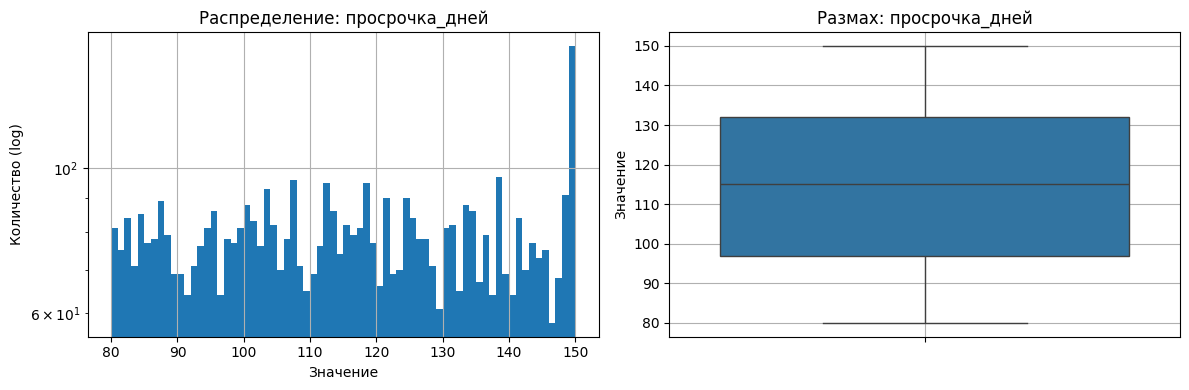

#### категориальные признаки

,ID,дата_начала_периода
count,5500,5500
unique,5500,73
top,IDF55109846,2018-12-01
freq,1,209


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54995533, IDF54964538, IDF550...",5500
1,дата_начала_периода,"[2014-12-01, 2015-06-01, 2018-03-01, 2019-09-0...",73


----------------------------------------------------------------------


### Анализ датафрейма: **транзакции**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
count,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000,577494.000000
mean,6177.123479,3507.682295,2993.862550,9263.099506,1128.116821,3604.437043,3682.487182,5414.896895
std,8835.871514,5710.755226,4541.119582,12299.732992,1557.157471,5005.896972,5567.979383,7190.882383
min,162.910000,62.180000,67.060000,286.110000,31.900000,108.400000,81.290000,166.260000
25%,1360.880000,583.480000,611.540000,2139.480000,245.059998,824.942500,700.632500,1250.850000
50%,2659.590000,1233.110000,1224.530000,4115.385000,476.890015,1590.120000,1397.065000,2398.330000
75%,6561.467500,3642.392500,3201.612500,9287.545000,1159.520020,3866.050000,3872.412500,5413.530000
max,86939.400000,55720.690000,47969.570000,101301.950000,14261.490234,54630.190000,52987.530000,60033.550000


,Признак,Уникальные значения,Кол-во
3,MCC_5411,"[5711.1, 5824.65, 5209.51, 5765.96, 5632.11, 7...",462655
0,MCC_5300,"[3267.59, 3196.58, 3550.54, 3385.98, 3214.84, ...",423534
7,MCC_другое,"[3657.35, 3322.61, 3467.06, 3354.44, 4352.9, 5...",406485
5,MCC_5722,"[2374.78, 2187.11, 2076.54, 2231.77, 2156.67, ...",359405
6,MCC_4900,"[4059.86, 4592.26, 3605.25, 2209.39, 1519.46, ...",353656
1,MCC_5814,"[1282.11, 2443.37, 4277.72, 4530.63, 4146.65, ...",345459
2,MCC_5812,"[1457.96, 1334.2, 1463.75, 1261.4, 1405.15, 23...",335475
4,MCC_3990,"[647.43, 1067.55, 1167.95, 986.99, 640.76, 633...",221493


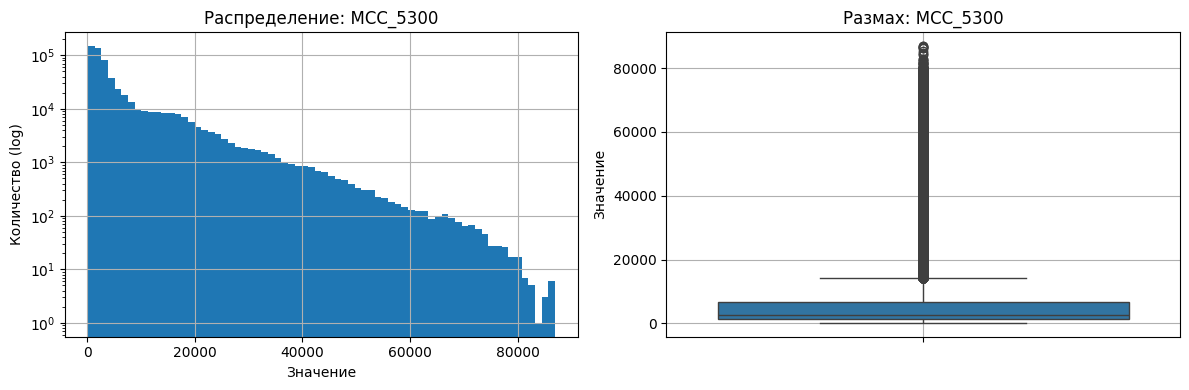

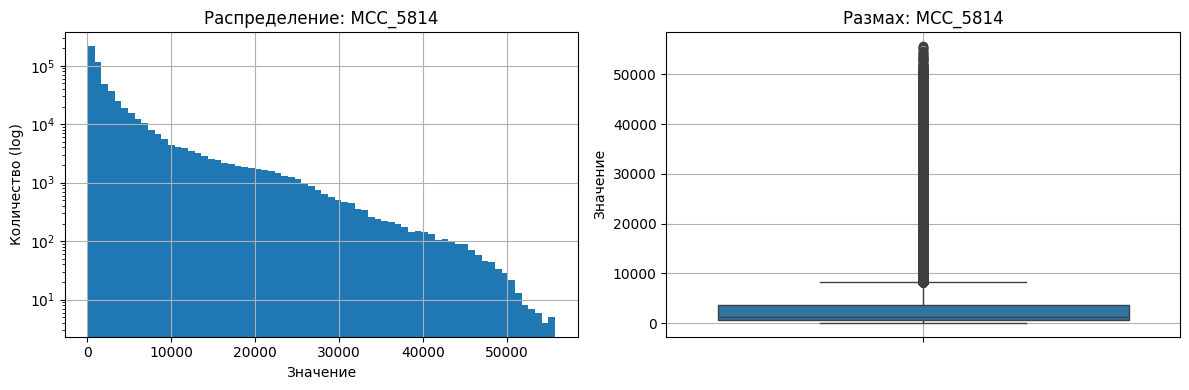

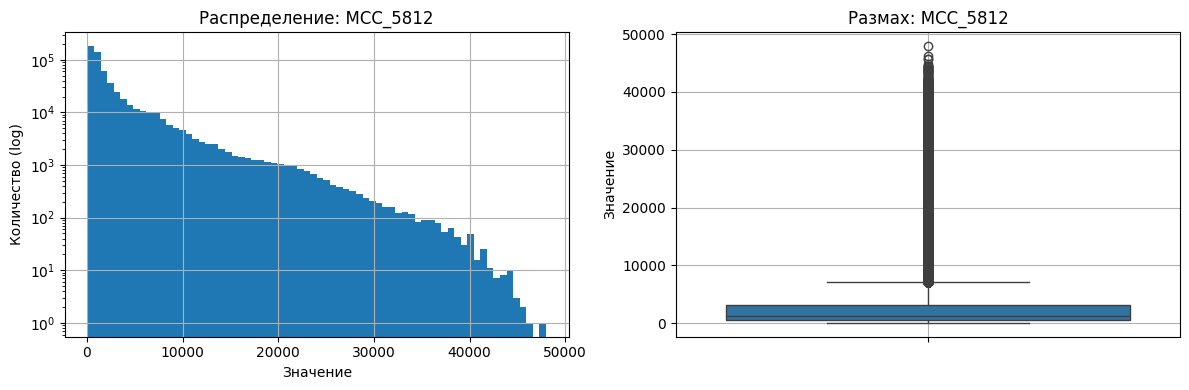

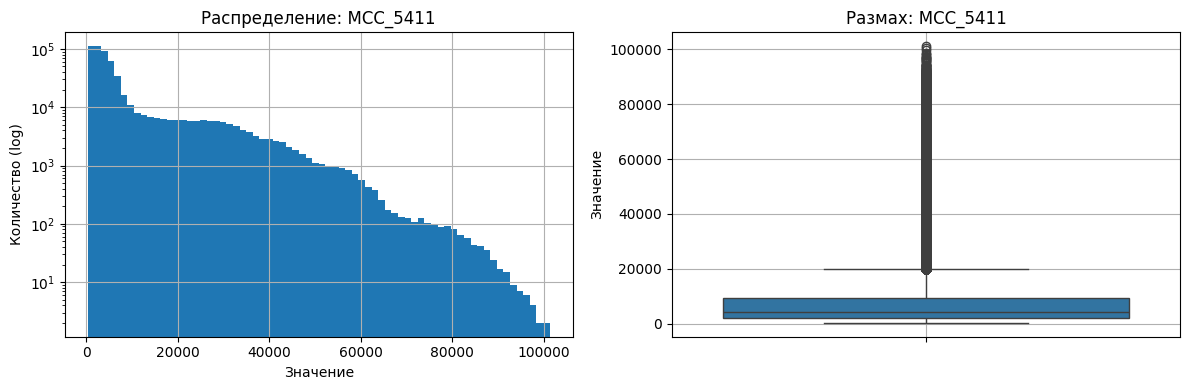

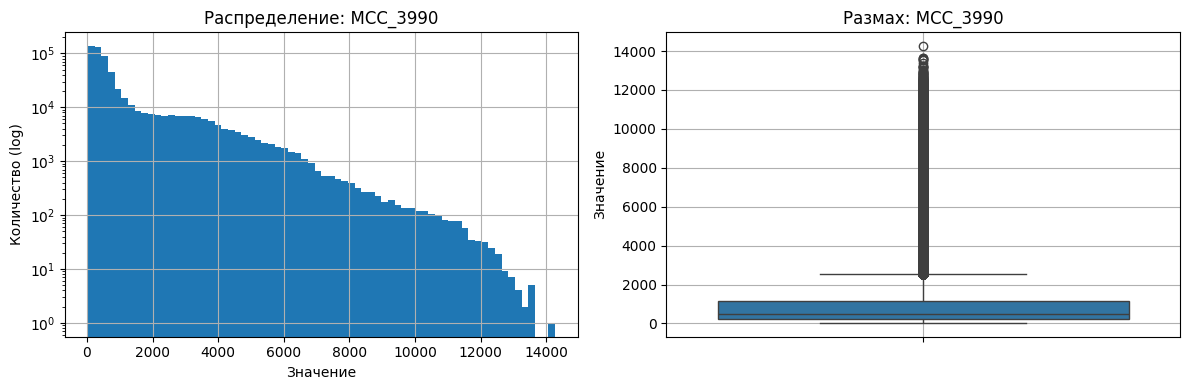

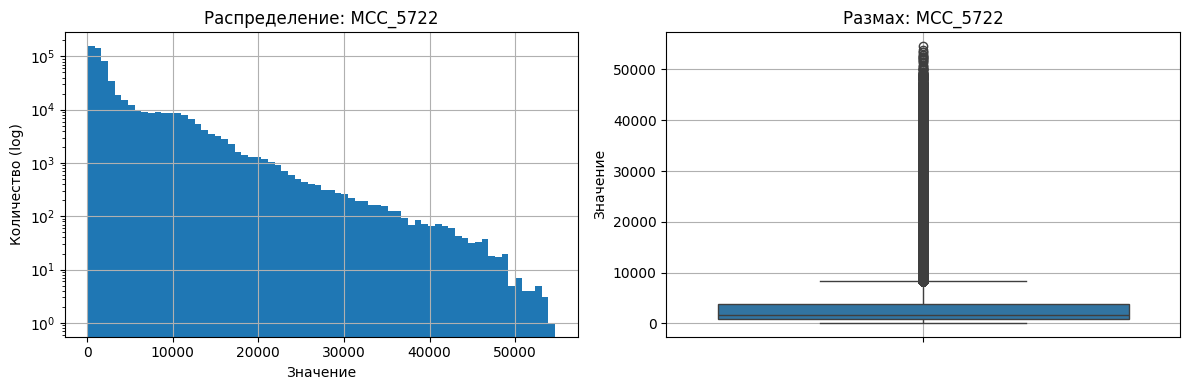

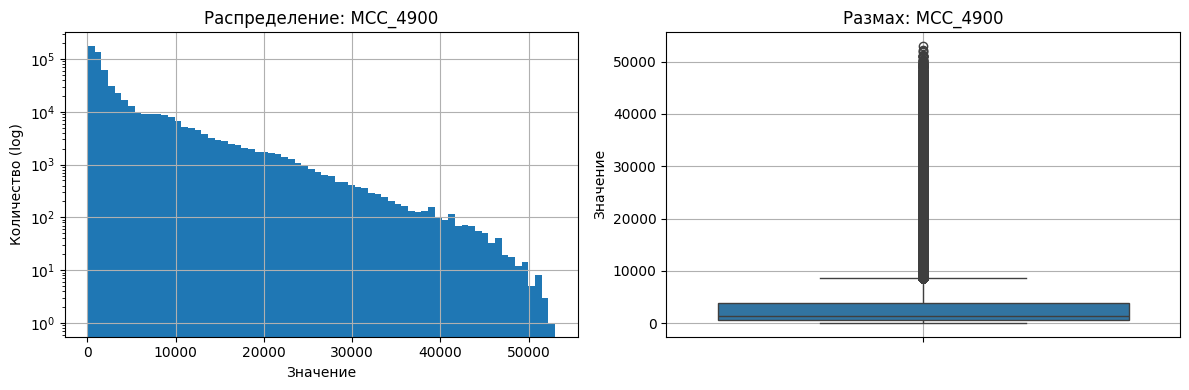

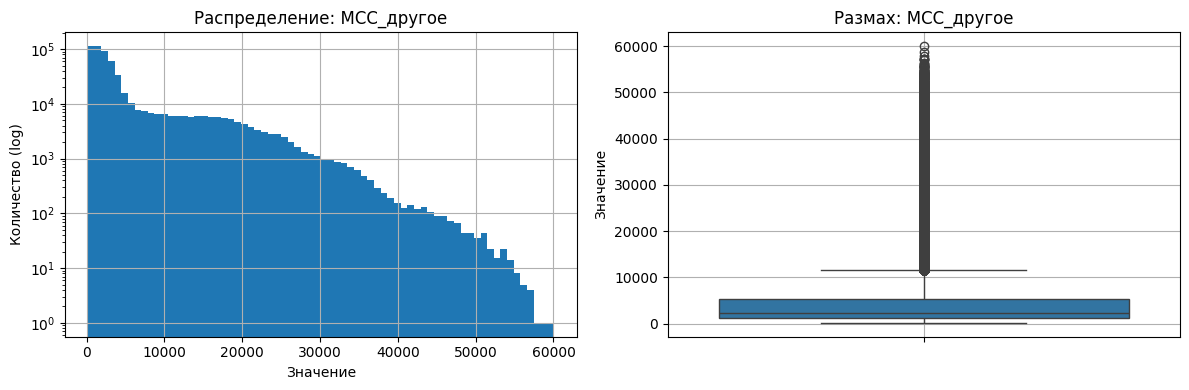

#### категориальные признаки

,ID,date
count,577494,577494
unique,13500,84
top,IDF55014574,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **описание клиента**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,возраст,наличие_иждивенцев
count,13500.000000,13500.000000
mean,41.304815,0.484741
std,15.096673,0.499786
min,18.000000,0.000000
25%,28.000000,0.000000
50%,40.000000,0.000000
75%,54.000000,1.000000
max,69.000000,1.000000


,Признак,Уникальные значения,Кол-во
0,возраст,"[41, 45, 34, 40, 66, 57, 18, 27, 25, 32, 23, 5...",52
1,наличие_иждивенцев,"[1, 0]",2


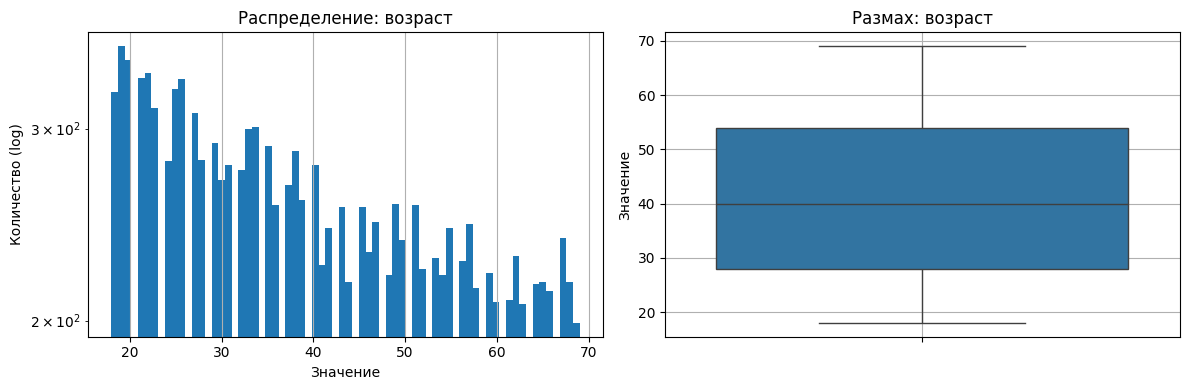

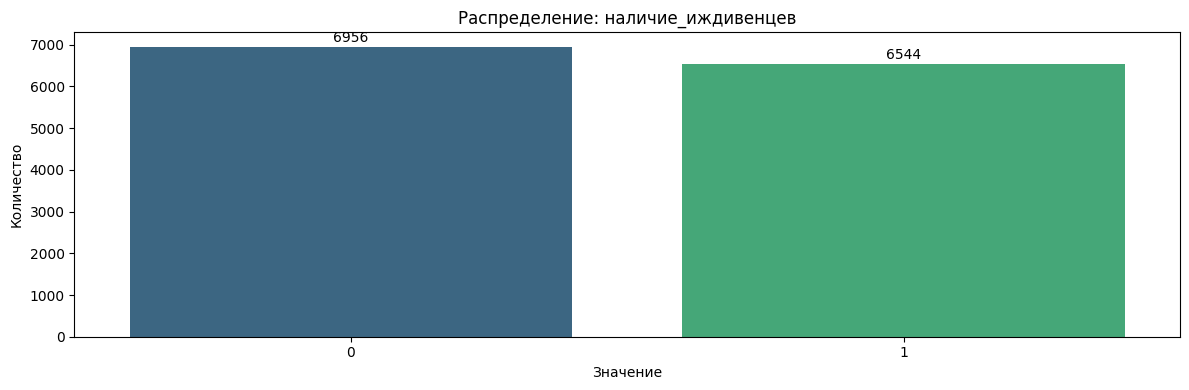

#### категориальные признаки

,ID,семейное_положение,дата_регистрации
count,13500,13500,13500
unique,13500,3,84
top,IDF55109846,нет семьи,2014-03-01
freq,1,4584,189


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
2,дата_регистрации,"[2013-05-01, 2017-12-01, 2013-11-01, 2018-08-0...",84
1,семейное_положение,"[разведённые, нет семьи, есть семья]",3


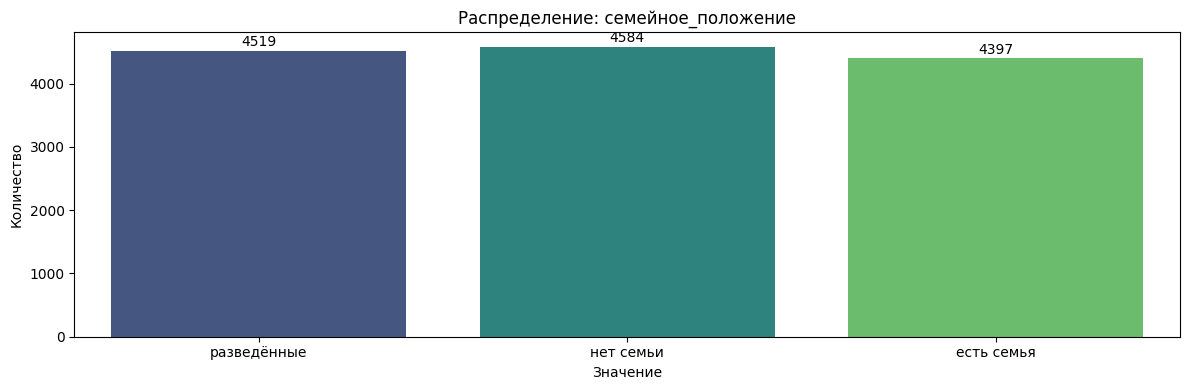

----------------------------------------------------------------------


### Анализ датафрейма: **описание кредита**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,доход,сумма_кредита
count,13500.000000,1.350000e+04
mean,79089.268593,1.993383e+06
std,40045.549462,1.061381e+06
min,15010.000000,7.500000e+04
25%,43347.000000,1.079329e+06
50%,77991.500000,2.032732e+06
75%,113615.500000,2.919236e+06
max,149988.000000,3.749400e+06


,Признак,Уникальные значения,Кол-во
1,сумма_кредита,"[1960785, 3375810, 401700, 1952655, 1107870, 3...",13140
0,доход,"[27035, 64502, 90477, 133475, 51324, 50694, 12...",12801


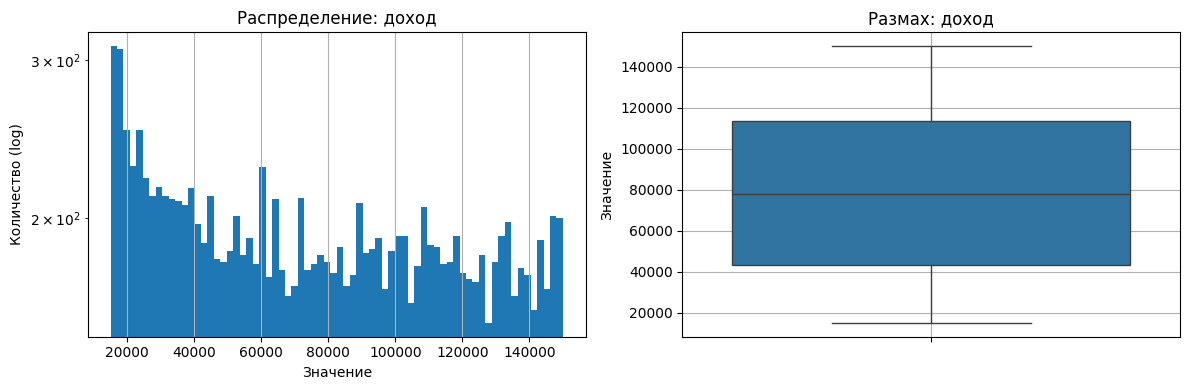

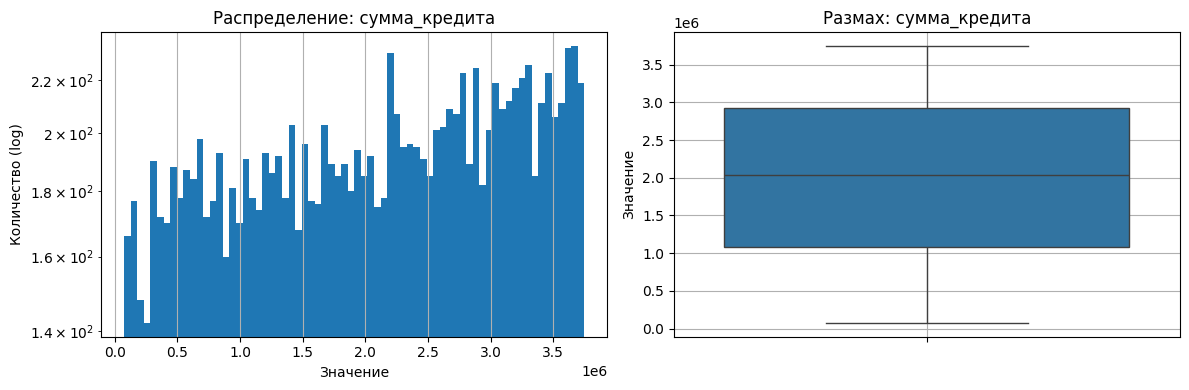

#### категориальные признаки

,ID
count,13500
unique,13500
top,IDF55109846
freq,1


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500


----------------------------------------------------------------------


### Анализ датафрейма: **наличие ипотеки**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,наличие_ипотеки
count,6609.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


,Признак,Уникальные значения,Кол-во
0,наличие_ипотеки,[1],1


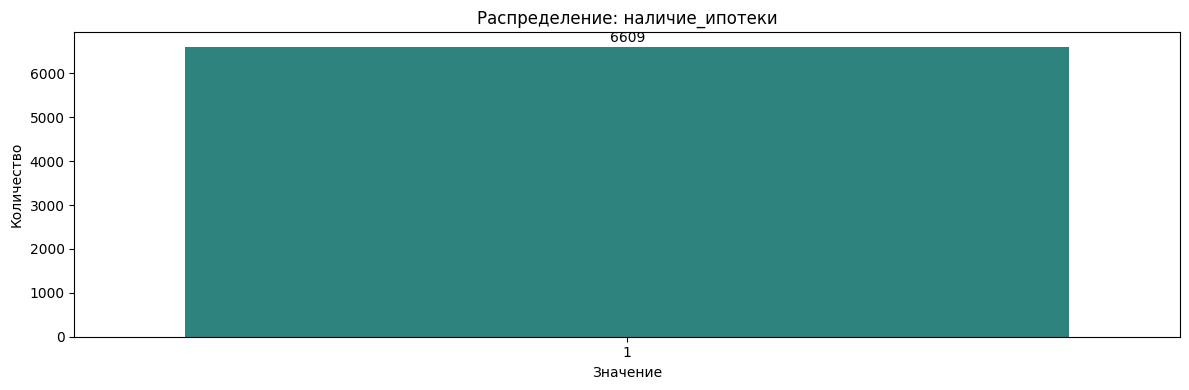

#### категориальные признаки

,ID,дата_открытия
count,6609,6609
unique,6609,84
top,IDF54896351,2018-12-01
freq,1,98


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF54896351, IDF54896367, IDF54896414, IDF548...",6609
1,дата_открытия,"[2013-03-01, 2018-01-01, 2018-02-01, 2019-02-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **кредитный рейтинг**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,кредитный_рейтинг
count,577494.000000
mean,603.190961
std,64.358896
min,343.000000
25%,558.000000
50%,600.000000
75%,646.000000
max,900.000000


,Признак,Уникальные значения,Кол-во
0,кредитный_рейтинг,"[692, 688, 666, 669, 658, 656, 655, 668, 663, ...",510


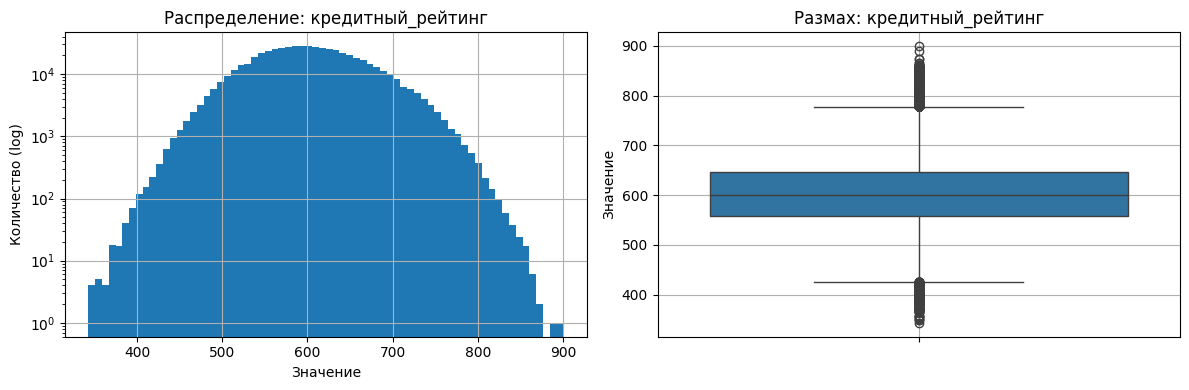

#### категориальные признаки

,ID,date
count,577494,577494
unique,13500,84
top,IDF55014574,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **макроданные**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,учетная_ставка,уровень_безработицы,инфляция
count,84.000000,84.000000,84.000000
mean,8.638517,5.175000,0.527500
std,2.466112,0.409488,0.570189
min,5.500000,4.300000,-0.540000
25%,7.250000,4.900000,0.262500
50%,7.750000,5.200000,0.425000
75%,10.329545,5.500000,0.635000
max,17.000000,6.000000,3.850000


,Признак,Уникальные значения,Кол-во
2,инфляция,"[0.97, 0.56, 0.34, 0.51, 0.66, 0.42, 0.82, 0.1...",62
0,учетная_ставка,"[5.5, 7.0, 7.068182, 7.5, 7.5869565, 8.0, 9.5,...",40
1,уровень_безработицы,"[5.7, 5.8, 5.9, 5.5, 5.4, 5.3, 5.2, 5.1, 5.6, ...",18


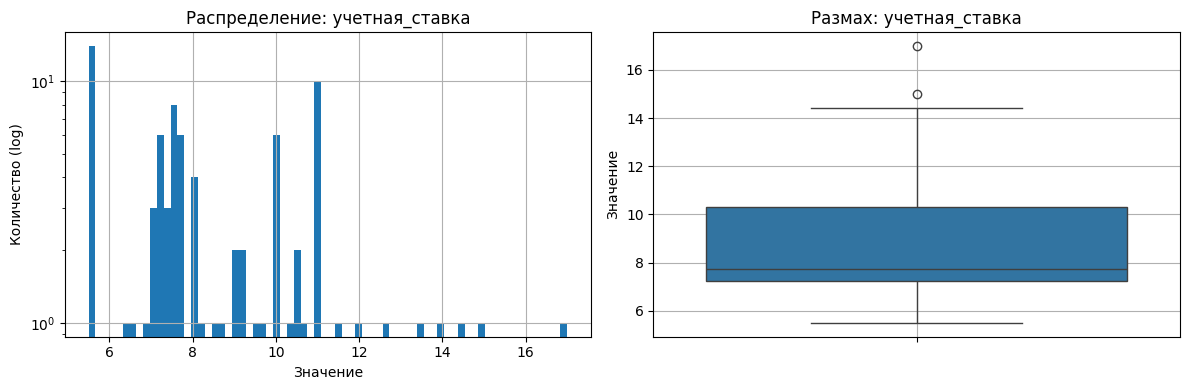

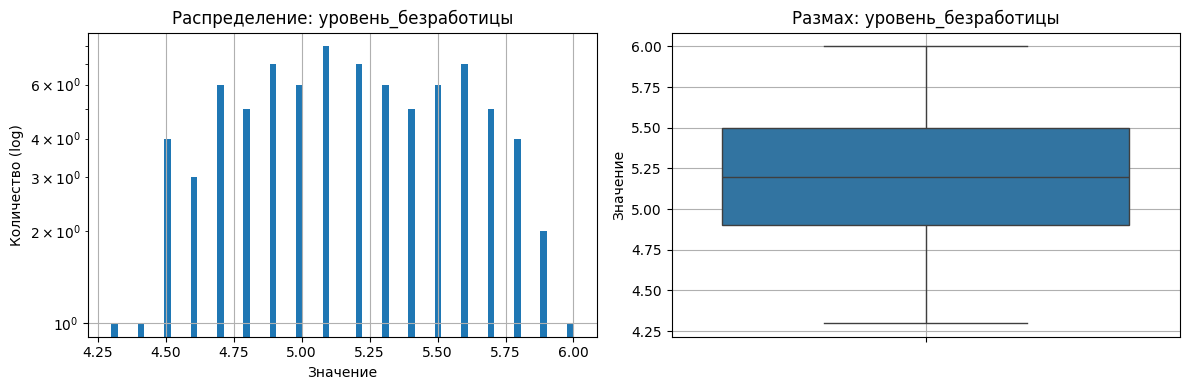

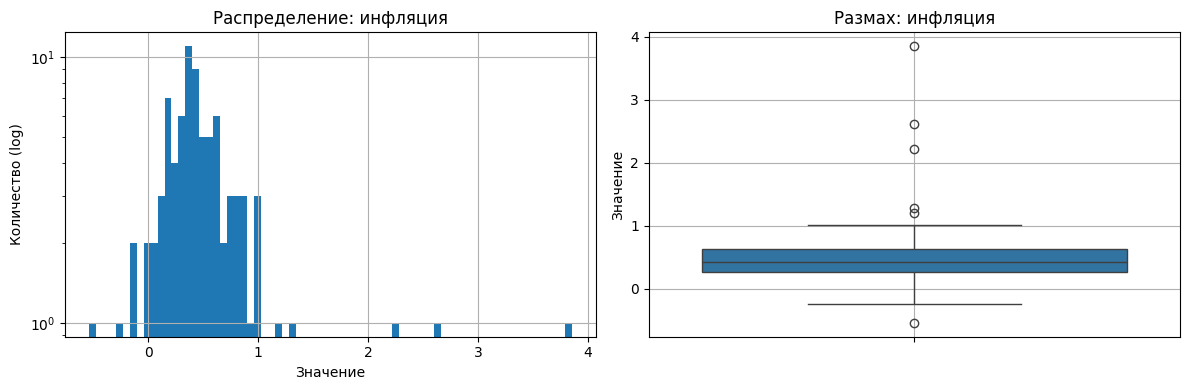

#### категориальные признаки

,date
count,84
unique,84
top,2013-01-01
freq,1


,Признак,Уникальные значения,Кол-во
0,date,"[2013-01-01, 2013-02-01, 2013-03-01, 2013-04-0...",84


----------------------------------------------------------------------


### Анализ датафрейма: **когортная сетка**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

Отсутствуют



#### категориальные признаки

,ID,score_date
count,577494,577494
unique,13500,84
top,IDF55014574,2019-12-01
freq,84,13500


,Признак,Уникальные значения,Кол-во
0,ID,"[IDF55109846, IDF54900291, IDF54995533, IDF550...",13500
1,score_date,"[2013-05-01, 2013-06-01, 2013-07-01, 2013-08-0...",84


----------------------------------------------------------------------


In [12]:
tables = [
    (loan_payment_credit, 'кредитный платеж'),
    (transactions, 'транзакции'),
    (client_description, 'описание клиента'),
    (credit_description, 'описание кредита'),
    (mortgage_presence, 'наличие ипотеки'),
    (credit_rating, 'кредитный рейтинг'),
    (macro_data, 'макроданные'),
    (cohort_grid, 'когортная сетка')
]

for table, name in tables:
    primary_analysis(table, name)

Вывод: технические пропуски и явные дубликаты отсутствуют во всех таблицах. Выборка включает 13 500 уникальных клиентов с равномерным распределением по возрасту (от 18 до 69 лет) и семейному статусу, при этом около 49% из них (6609 человек) имеют ипотеку. Когортная сетка подтверждает полную структуру временных рядов: для каждого из 13 500 id представлено ровно 84 ежемесячных наблюдения, что формирует массив из 577 494 записей для анализа динамики транзакций и рейтинга. В транзакционных данных по всем MCC-кодам выявлены экстремальные правосторонние выбросы (максимумы до 101 тыс. при средних значениях 6–9 тыс.), в то время как кредитный рейтинг (от 343 до 900) распределен нормально. Целевые события дефолта (5500 записей) зафиксированы строго в интервале просрочки от 80 до 150 дней, а макроэкономический фон за 7 лет отражает существенные колебания учетной ставки от 5,5% до 17%, и периоды инфляции до 4%, и дефляции (-0.54%), колебания безработицы в пределах 4,3–6,0%, так что модель сможет учесть влияние кризисов на платежеспособность.

## Объединение таблиц & Создание новых признаков

Получение информации по одному пользователю для сверки итоговой таблицы

In [13]:
id = 'IDF54995533'

display(loan_payment_credit[loan_payment_credit['ID'] == id])
display(transactions[transactions['ID'] == id])
display(client_description[client_description['ID'] == id])
display(credit_description[credit_description['ID'] == id])
display(mortgage_presence[mortgage_presence['ID'] == id])
display(credit_rating[credit_rating['ID'] == id].shift(1))
display(cohort_grid[cohort_grid['ID'] == id])

,ID,дата_начала_периода,просрочка_дней
1,IDF54995533,2015-06-01,121


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
105,IDF54995533,2013-11-01,10462.39,3953.09,4397.23,18684.95,1940.729980,7065.21,12791.49,10011.65
106,IDF54995533,2013-12-01,10654.05,9485.75,4732.57,18766.35,3256.929932,7294.09,13692.72,10987.01
107,IDF54995533,2014-01-01,11271.94,13135.86,4566.76,17635.32,3928.520020,7487.61,12315.87,11105.60
108,IDF54995533,2014-02-01,11395.93,16727.66,4359.29,18831.08,3428.419922,6640.08,8793.45,10951.81
109,IDF54995533,2014-03-01,11954.18,13973.07,4537.26,18763.97,2199.020020,7118.18,5052.48,14473.56
...,...,...,...,...,...,...,...,...,...,...
174,IDF54995533,2019-08-01,3225.93,548.76,1075.09,2701.34,312.709991,1261.00,746.07,1816.10
175,IDF54995533,2019-09-01,2150.58,549.70,597.93,2912.24,315.250000,1851.32,772.65,1664.07
176,IDF54995533,2019-10-01,1540.66,541.35,597.93,2317.04,267.809998,2053.63,672.70,1480.44
177,IDF54995533,2019-11-01,1324.59,508.24,615.50,2491.62,287.619995,938.25,1663.38,1418.46


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
2,IDF54995533,34,разведённые,1,2013-11-01


,ID,доход,сумма_кредита
2,IDF54995533,90477,401700


,ID,дата_открытия,наличие_ипотеки
2559,IDF54995533,2013-11-01,1


,ID,date,кредитный_рейтинг
105,NaN,NaN,NaN
106,IDF54995533,2013-11-01,686.0
107,IDF54995533,2013-12-01,662.0
108,IDF54995533,2014-01-01,648.0
109,IDF54995533,2014-02-01,651.0
...,...,...,...
174,IDF54995533,2019-07-01,547.0
175,IDF54995533,2019-08-01,543.0
176,IDF54995533,2019-09-01,542.0
177,IDF54995533,2019-10-01,543.0


,ID,score_date
105,IDF54995533,2013-11-01
106,IDF54995533,2013-12-01
107,IDF54995533,2014-01-01
108,IDF54995533,2014-02-01
109,IDF54995533,2014-03-01
...,...,...
174,IDF54995533,2019-08-01
175,IDF54995533,2019-09-01
176,IDF54995533,2019-10-01
177,IDF54995533,2019-11-01


Формирование итоговой таблицы

In [14]:
def merge_tables(
    cohort_grid, 
    loan_payment_credit, 
    client_description, 
    credit_description,
    mortgage_presence, 
    macro_data,
    credit_rating,
    transactions
):
    initial_len = len(cohort_grid)
    
    for df, col in [
        (cohort_grid, 'score_date'),
        (loan_payment_credit, 'дата_начала_периода'),
        (client_description, 'дата_регистрации'),
        (mortgage_presence, 'дата_открытия'),
        (macro_data, 'date'),
        (credit_rating, 'date'),
        (transactions, 'date'),
    ]:
        df[col] = pd.to_datetime(df[col])

    first_defaults = (
        loan_payment_credit[loan_payment_credit['просрочка_дней'] >= 90]
        .sort_values(["ID", "дата_начала_периода"])
        .drop_duplicates("ID", keep="first")
        [['ID', 'дата_начала_периода']]
    )

    df = pd.merge(cohort_grid, first_defaults, on='ID', how='left')

    df['target'] = (
        (df['дата_начала_периода'] >= df['score_date']) & 
        (df['дата_начала_периода'] < df['score_date'] + pd.Timedelta(days=365))
    ).astype(int)

    df = df[~(df['дата_начала_периода'] < df['score_date'])].copy()
    after_filter_len = len(df)

    for tbl in [client_description, credit_description, mortgage_presence]:
        df = df.merge(tbl, on='ID', how='left')

    df['client_tenure_days'] = (df['score_date'] - df['дата_регистрации']).dt.days.fillna(-1)

    df['mortgage_age_days'] = (df['score_date'] - df['дата_открытия']).dt.days
    no_mortgage_mask = (df['дата_открытия'].isna()) | (df['дата_открытия'] >= df['score_date'])
    df.loc[no_mortgage_mask, 'mortgage_age_days'] = -1
    df['наличие_ипотеки'] = (~no_mortgage_mask).astype(int)

    df = df.sort_values('score_date')

    df = pd.merge_asof(
        df, macro_data.sort_values('date'),
        left_on='score_date', right_on='date',
        direction='backward', allow_exact_matches=False
    ).drop(columns=['date'])

    for tbl in [credit_rating, transactions]:
        df = pd.merge_asof(
            df, tbl.sort_values('date'),
            left_on='score_date', right_on='date', by='ID',
            direction='backward', allow_exact_matches=False
    ).drop(columns=['date'])
    df['кредитный_рейтинг'] = df['кредитный_рейтинг'].fillna(-1)

    mcc_cols = [col for col in df.columns if 'MCC_' in col]
    df[mcc_cols] = df[mcc_cols].fillna(0)
    df['total_mcc_spent'] = df[mcc_cols].sum(axis=1)
    
    df['leisure_to_base_ratio'] = (df['MCC_5814'] + df['MCC_5812']) / (df['MCC_5411'] + 1e-9)

    df['loan_to_income_ratio'] = df['сумма_кредита'] / (df['доход'] + 1e-9)

    df['spend_drop_ratio'] = df['total_mcc_spent'] / (df.groupby('ID')['total_mcc_spent'].cummax() + 1e-9)

    df = df.drop(columns=['дата_начала_периода', 'дата_открытия', 'дата_регистрации'])
    df = df.dropna()

    final_len = len(df)
    print(f"Начальный размер: {initial_len}")
    final_without_default = initial_len - after_filter_len + final_len
    print(f'После соединения всех таблиц без фильтра дефолтов: {final_without_default} (разница с исходным {initial_len - final_without_default} ({(1 - final_without_default / initial_len) * 100:.2f}%))')
    print(f"После фильтра дефолтов: {after_filter_len}")
    print(f"Итоговый размер: {final_len}")
    print(f"Потеряно строк: {initial_len - final_len} ({(1 - final_len / initial_len) * 100:.2f}%)")

    return df

In [15]:
df = merge_tables(
    cohort_grid, 
    loan_payment_credit, 
    client_description, 
    credit_description,
    mortgage_presence,
    macro_data,
    credit_rating,
    transactions
)

Начальный размер: 577494
После соединения всех таблиц без фильтра дефолтов: 577342 (разница с исходным 152 (0.03%))
После фильтра дефолтов: 438379
Итоговый размер: 438227
Потеряно строк: 139267 (24.12%)


In [16]:
show_missing_stats(df)

'Пропусков в данных нет'

In [17]:
df.head()

,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,client_tenure_days,mortgage_age_days,учетная_ставка,уровень_безработицы,инфляция,кредитный_рейтинг,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,total_mcc_spent,leisure_to_base_ratio,loan_to_income_ratio,spend_drop_ratio
152,IDF55114026,2013-02-01,0,65,нет семьи,0,96507,2391435,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,24.779912,0.0
153,IDF54976809,2013-02-01,0,26,нет семьи,0,60433,3297510,0,31,-1.0,5.5,5.7,0.97,571.0,7213.61,2824.62,2959.81,12713.93,1311.010010,4816.61,8975.66,7689.17,48504.420010,0.454968,54.564725,1.0
154,IDF55052704,2013-02-01,0,34,нет семьи,0,61885,3640665,0,31,-1.0,5.5,5.7,0.97,806.0,6762.73,2505.00,2943.34,12277.45,1425.709961,4216.30,8098.78,6419.73,44649.039961,0.443768,58.829523,1.0
155,IDF55060576,2013-02-01,0,24,разведённые,0,143372,1269390,0,31,-1.0,5.5,5.7,0.97,784.0,17812.70,6539.69,7365.39,29840.35,3331.709961,11309.75,20508.71,17894.33,114602.629961,0.465982,8.853821,1.0
156,IDF54960225,2013-02-01,1,57,нет семьи,0,136215,816345,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,5.993062,0.0


In [18]:
df[df['ID'] == 'IDF54995533']

,ID,score_date,target,возраст,семейное_положение,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,client_tenure_days,mortgage_age_days,учетная_ставка,уровень_безработицы,инфляция,кредитный_рейтинг,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,total_mcc_spent,leisure_to_base_ratio,loan_to_income_ratio,spend_drop_ratio
9057,IDF54995533,2013-11-01,0,34,разведённые,1,90477,401700,0,0,-1.0,5.500000,5.4,0.57,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,4.439802,0.000000
10710,IDF54995533,2013-12-01,0,34,разведённые,1,90477,401700,1,30,30.0,5.500000,5.5,0.56,686.0,10462.39,3953.09,4397.23,18684.95,1940.729980,7065.21,12791.49,10011.65,69306.739980,0.446901,4.439802,1.000000
14425,IDF54995533,2014-01-01,0,34,разведённые,1,90477,401700,1,61,61.0,5.500000,5.6,0.51,662.0,10654.05,9485.75,4732.57,18766.35,3256.929932,7294.09,13692.72,10987.01,78869.469932,0.757650,4.439802,1.000000
15871,IDF54995533,2014-02-01,0,34,разведённые,1,90477,401700,1,92,92.0,5.500000,5.6,0.59,648.0,11271.94,13135.86,4566.76,17635.32,3928.520020,7487.61,12315.87,11105.60,81447.480020,1.003816,4.439802,1.000000
17261,IDF54995533,2014-03-01,0,34,разведённые,1,90477,401700,1,120,120.0,5.500000,5.5,0.70,651.0,11395.93,16727.66,4359.29,18831.08,3428.419922,6640.08,8793.45,10951.81,81127.719922,1.119795,4.439802,0.996074
19757,IDF54995533,2014-04-01,0,34,разведённые,1,90477,401700,1,151,151.0,7.000000,5.4,1.02,662.0,11954.18,13973.07,4537.26,18763.97,2199.020020,7118.18,5052.48,14473.56,78071.720020,0.986483,4.439802,0.958553
24148,IDF54995533,2014-05-01,0,34,разведённые,1,90477,401700,1,181,181.0,7.068182,4.9,0.90,660.0,10832.39,7839.41,6966.39,26254.69,2040.199951,6908.19,5242.03,16413.95,82497.249951,0.563930,4.439802,1.000000
24358,IDF54995533,2014-06-01,0,34,разведённые,1,90477,401700,1,212,212.0,7.500000,5.0,0.90,655.0,13916.97,4409.44,11558.86,29463.69,2146.669922,7423.89,6022.73,14452.58,89394.829922,0.541965,4.439802,1.000000
29736,IDF54995533,2014-07-01,1,34,разведённые,1,90477,401700,1,242,242.0,7.500000,5.1,0.62,662.0,24418.89,4466.03,15256.66,28450.04,2504.550049,7844.90,6302.32,12907.27,102150.660049,0.693239,4.439802,1.000000
30985,IDF54995533,2014-08-01,1,34,разведённые,1,90477,401700,1,273,273.0,7.586957,5.0,0.49,671.0,27109.15,4489.26,14670.41,21647.59,2358.870117,8511.22,6421.77,12110.11,97318.380117,0.885072,4.439802,0.952695


Итоговая витрина сформирована с минимальной технической потерей данных: на этапе объединения таблиц отсеяно всего 152 строки (0.03%). Сокращение выборки с 577 494 до 438 227 строк (общая потеря 24.12%) является обоснованным, так как вызвано исключением клиентов, уже находившихся в дефолте на момент скоринга. Логика обработки пропусков в таблице построена на принципе исключения утечек из будущего и сохранении физического смысла данных: транзакции заполнены нулями, так как отсутствие записи означает отсутствие трат; стаж клиента, возраст ипотеки и кредитный рейтинг заполнены значением -1, чтобы модель могла четко отличить отсутствие истории или продукта от новых записей с нулевым стажем. Пропуски в макроданных (0.03%), возникшие из-за временного смещения, были удалены через dropna(), так как любой метод их заполнения (например, значениями из следующего месяца) привел бы к использованию будущей информации при прогнозировании. В результате получена чистая, обогащенная признаками таблица, полностью готовая к обучению.

## Анализ итоговой таблицы

In [19]:
eda_df = df.copy()

eda_df = eda_df.drop(columns='ID')

In [20]:
target_desc = eda_df['target'].describe()

target_desc

count    438227.000000
mean          0.112622
std           0.316131
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: target, dtype: float64

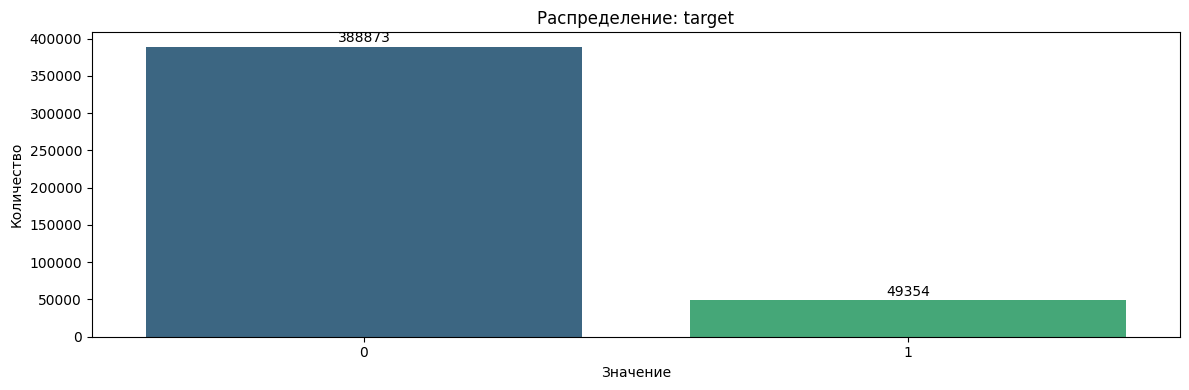

In [21]:
create_cat_plot(eda_df, 'target')

In [22]:
target_counts = eda_df['target'].value_counts()

print(f'Дефолта не было: {target_counts[0] / target_desc['count'] * 100:.0f}%')
print(f'Дефолт был: {target_counts[1] / target_desc['count'] * 100:.0f}%')

Дефолта не было: 89%
Дефолт был: 11%


Явный дисбаланс классов в сторону клиентов банка, у которых не было дефолта. Соотношение почти 1:10.

### Анализ датафрейма: **Итоговый dataframe**

#### пропуски

'Пропусков в данных нет'

#### дубликаты

Явные дубликаты строк: 0


#### числовые признаки

,target,возраст,наличие_иждивенцев,доход,сумма_кредита,наличие_ипотеки,client_tenure_days,mortgage_age_days,учетная_ставка,уровень_безработицы,инфляция,кредитный_рейтинг,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,total_mcc_spent,leisure_to_base_ratio,loan_to_income_ratio,spend_drop_ratio
count,438227.000000,438227.000000,438227.000000,438227.000000,4.382270e+05,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000,438227.000000
mean,0.112622,42.992518,0.496316,80756.421270,1.934256e+06,0.479859,754.620993,374.458780,8.783224,5.060837,0.435474,592.315711,7400.777174,4236.589960,3586.688299,11127.042053,1358.949463,4314.758092,4450.074883,6507.159926,42982.039939,0.685651,34.797899,0.419565
std,0.316131,15.156725,0.499987,39664.778998,1.064197e+06,0.499595,603.754275,569.346781,2.047549,0.411162,0.514232,123.828175,9786.669938,6353.834742,5044.821627,13547.341734,1717.854126,5534.501371,6170.295785,7919.333098,51422.979338,0.247870,35.407643,0.427034
min,0.000000,18.000000,0.000000,15010.000000,7.500000e+04,0.000000,0.000000,-1.000000,5.500000,4.300000,-0.540000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.506239,0.000000
25%,0.000000,30.000000,0.000000,45639.000000,1.013505e+06,0.000000,244.000000,-1.000000,7.437500,4.700000,0.200000,559.000000,1536.525000,650.900000,685.230000,2433.155000,277.885010,933.695000,788.680000,1420.940000,9544.310013,0.488540,12.462726,0.079841
50%,0.000000,43.000000,0.000000,80473.000000,1.939365e+06,0.000000,608.000000,-1.000000,7.750000,5.000000,0.360000,606.000000,3163.100000,1561.610000,1476.140000,4842.910000,565.659973,1876.010000,1691.880000,2824.440000,18812.110012,0.657954,23.853015,0.113963
75%,0.000000,56.000000,1.000000,115066.000000,2.851905e+06,1.000000,1185.000000,607.000000,10.000000,5.400000,0.560000,655.000000,9637.990000,4961.225000,4447.890000,15687.820000,1886.434998,5849.555000,5717.115000,9202.025000,61495.605022,0.902249,42.838411,0.973246
max,1.000000,69.000000,1.000000,149988.000000,3.749400e+06,1.000000,2525.000000,2525.000000,17.000000,6.000000,3.850000,900.000000,86939.400000,55720.690000,47969.570000,101301.950000,14261.490234,54630.190000,52987.530000,60033.550000,309029.080059,1.383141,242.970580,1.000000


,Признак,Уникальные значения,Кол-во
21,leisure_to_base_ratio,"[0.0, 0.45496789741642, 0.4437680462962224, 0....",424880
20,total_mcc_spent,"[0.0, 48504.42000976563, 44649.0399609375, 114...",424638
15,MCC_5411,"[0.0, 12713.93, 12277.45, 29840.35, 28906.28, ...",372977
12,MCC_5300,"[0.0, 7213.61, 6762.73, 17812.7, 16010.97, 190...",352363
19,MCC_другое,"[0.0, 7689.17, 6419.73, 17894.33, 16282.1, 191...",343722
23,spend_drop_ratio,"[0.0, 0.9999999999999795, 0.9999999999999777, ...",329548
17,MCC_5722,"[0.0, 4816.61, 4216.3, 11309.75, 10893.44, 115...",315407
18,MCC_4900,"[0.0, 8975.66, 8098.78, 20508.71, 19694.13, 23...",312075
13,MCC_5814,"[0.0, 2824.62, 2505.0, 6539.69, 6518.82, 6663....",305340
14,MCC_5812,"[0.0, 2959.81, 2943.34, 7365.39, 6361.28, 8206...",299144


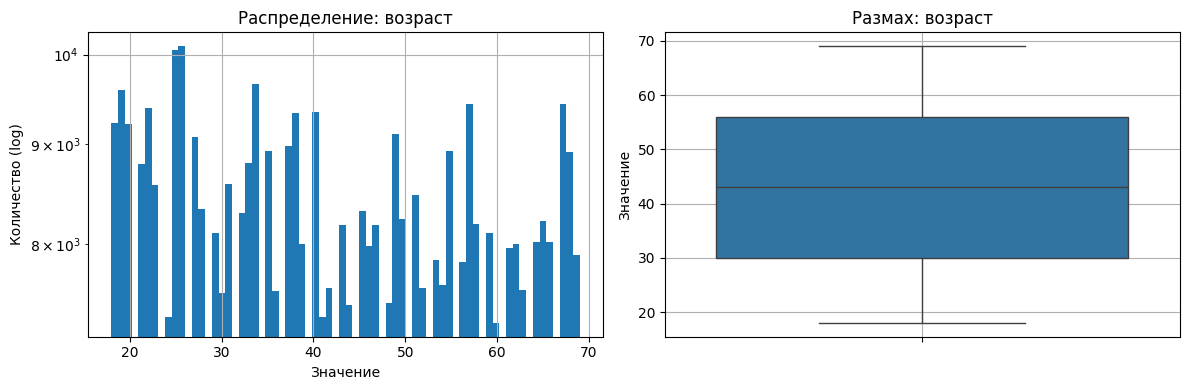

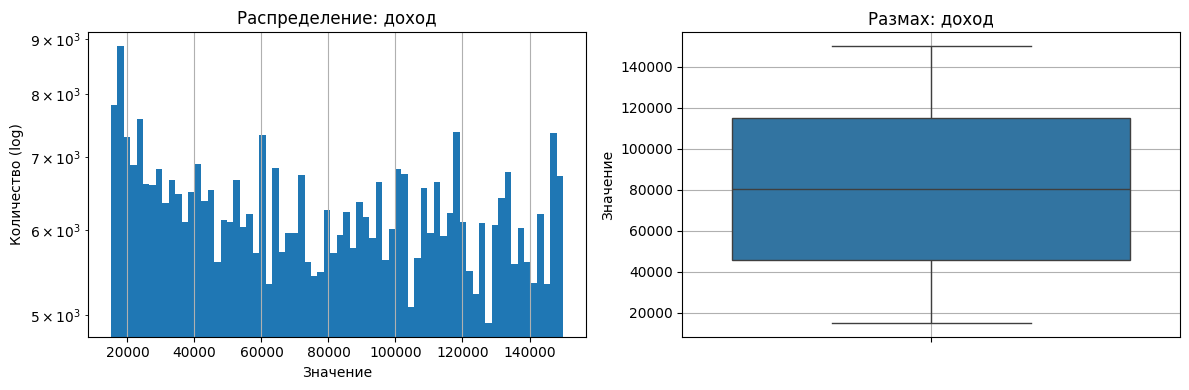

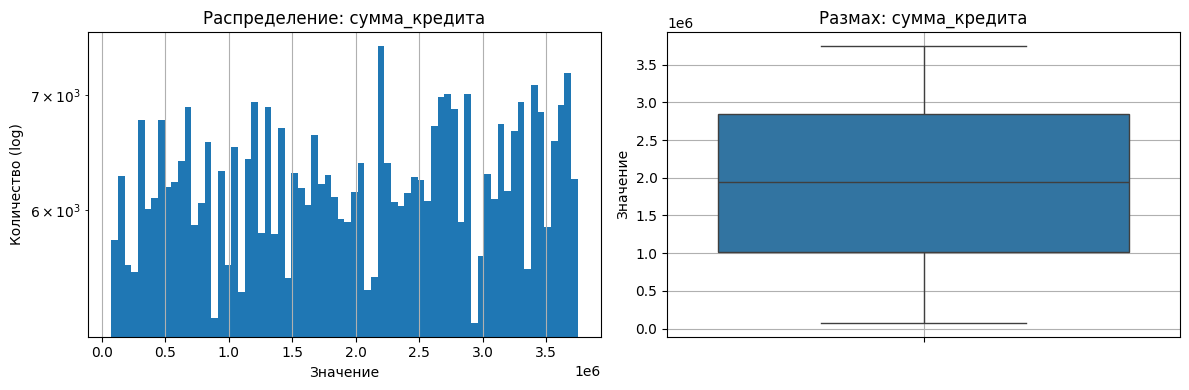

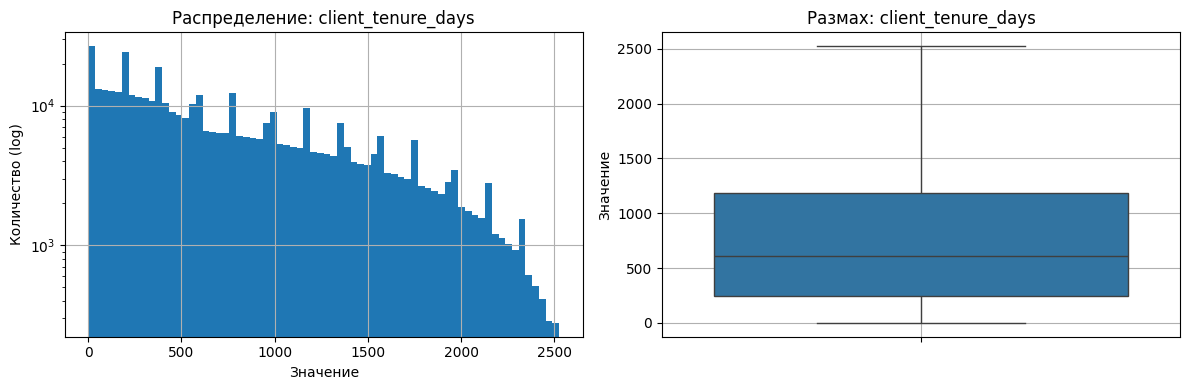

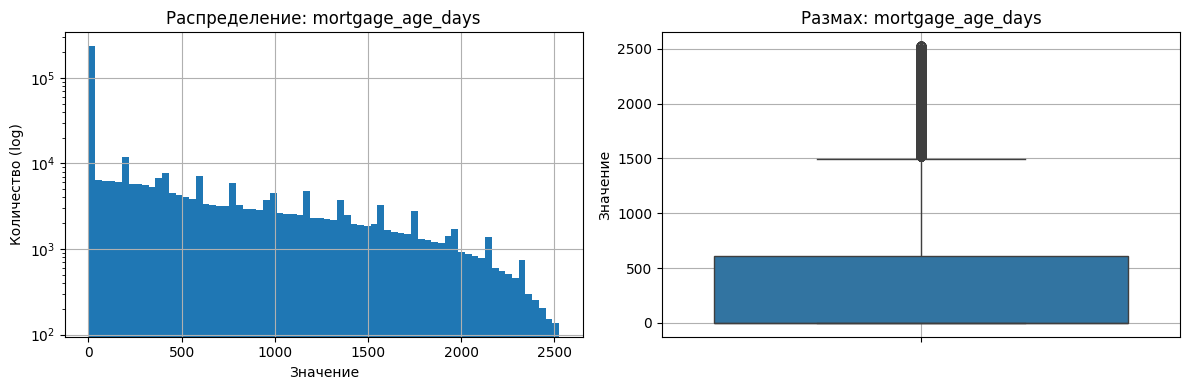

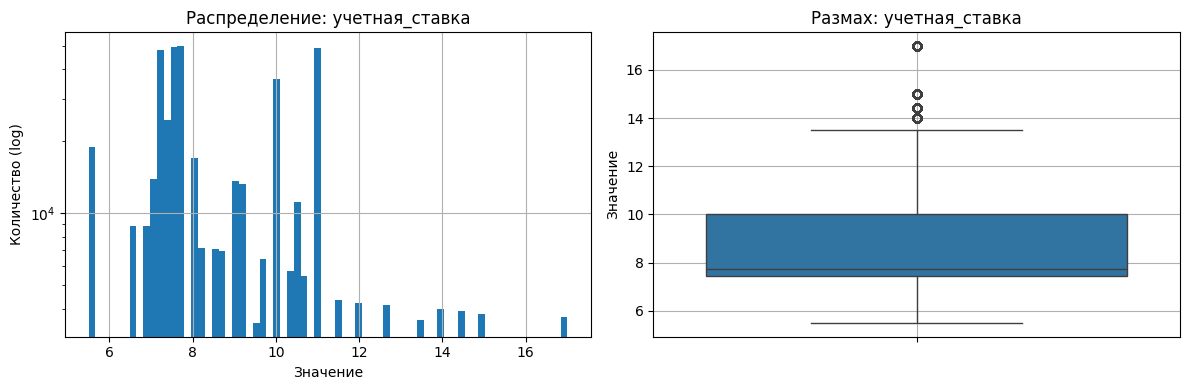

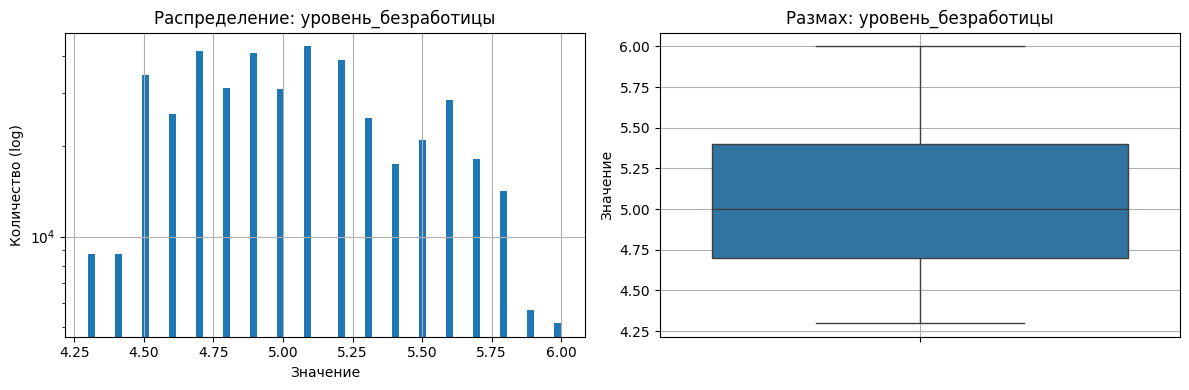

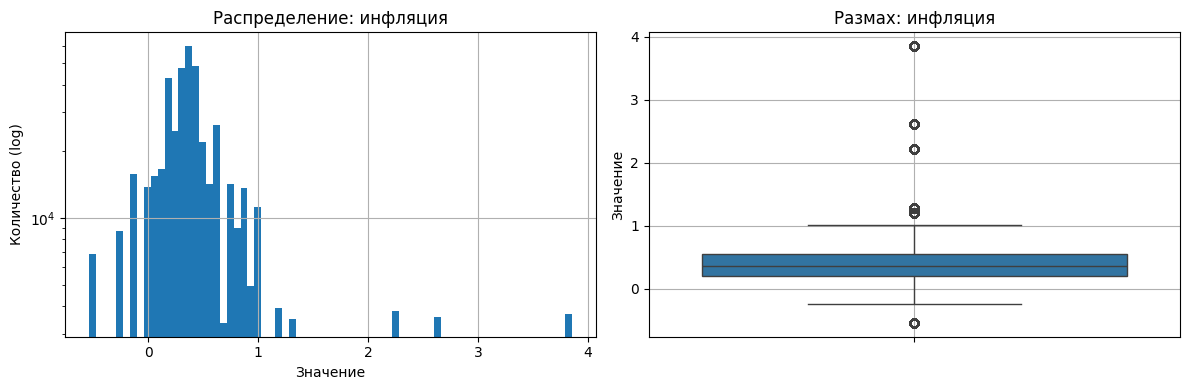

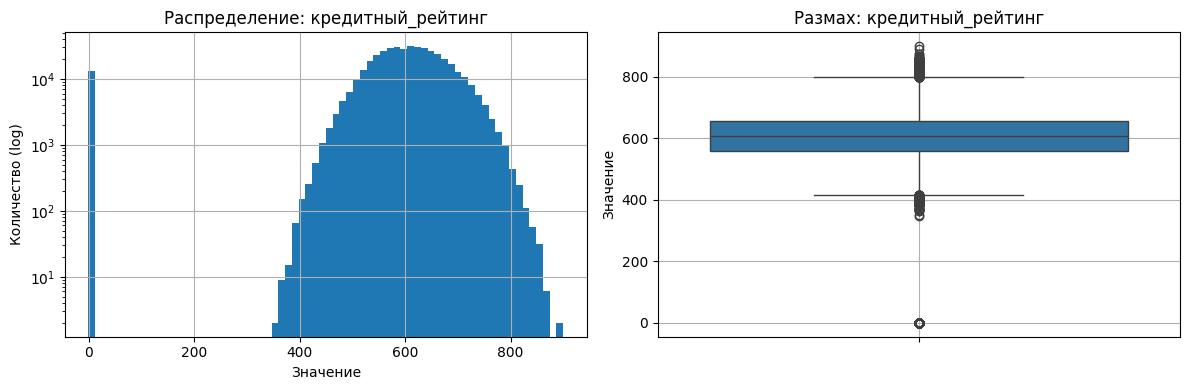

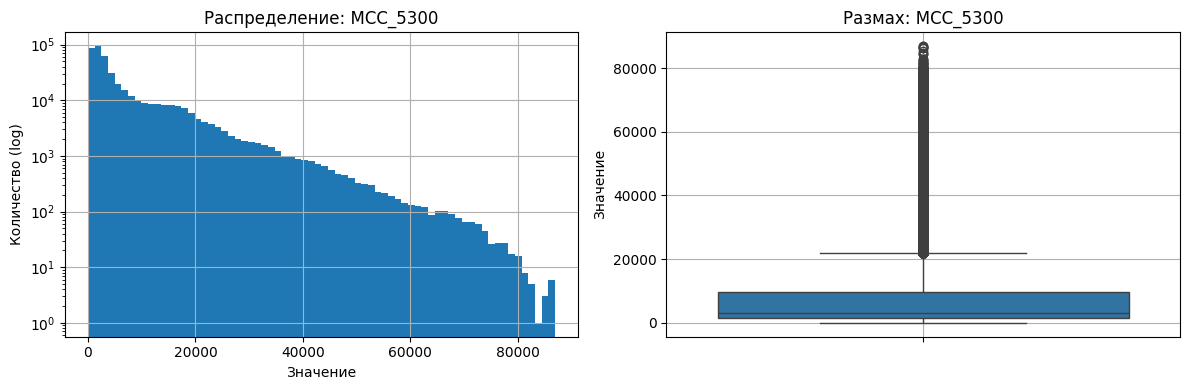

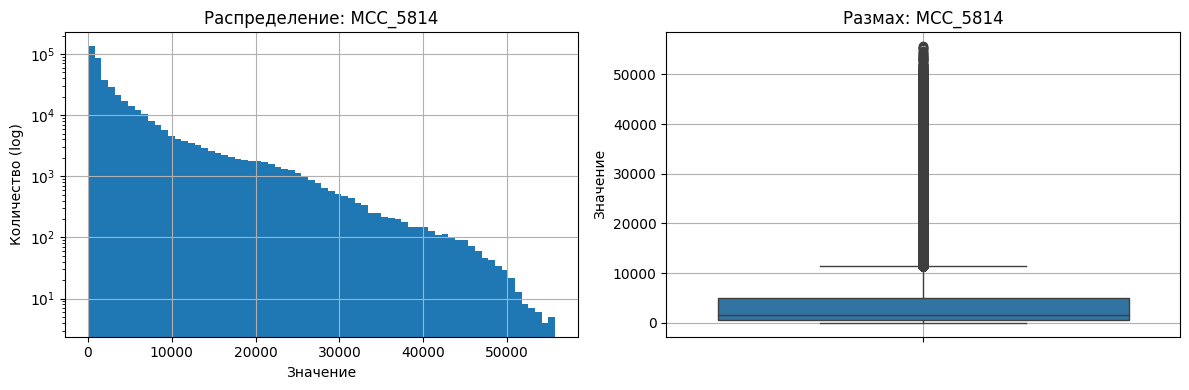

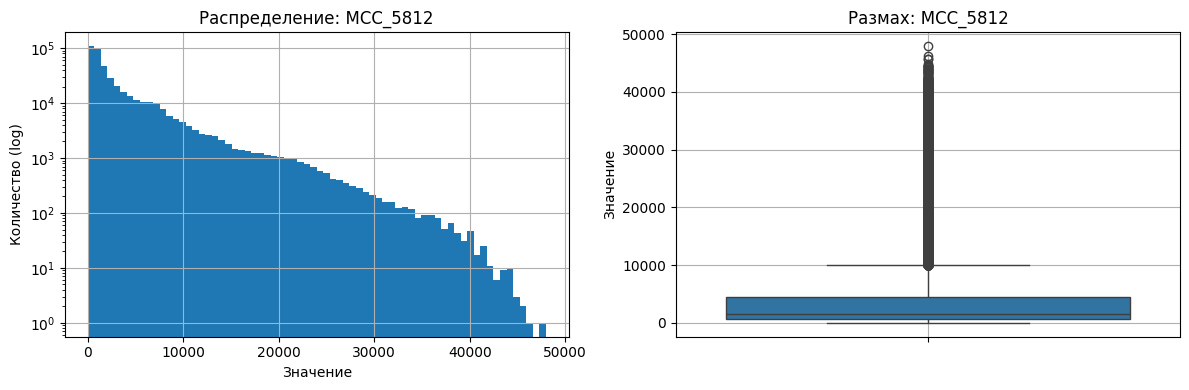

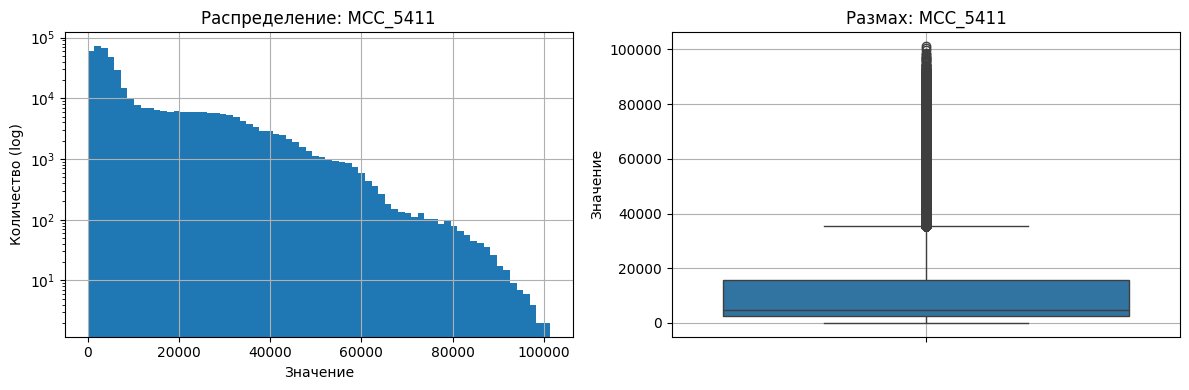

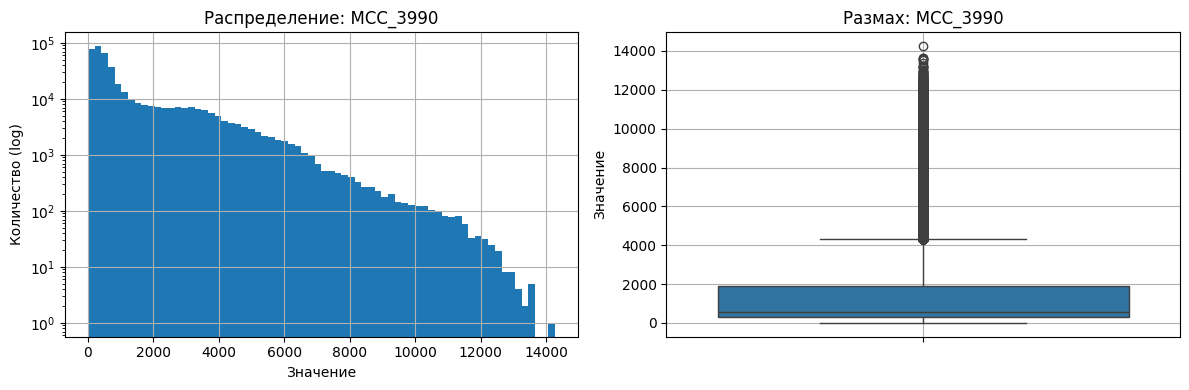

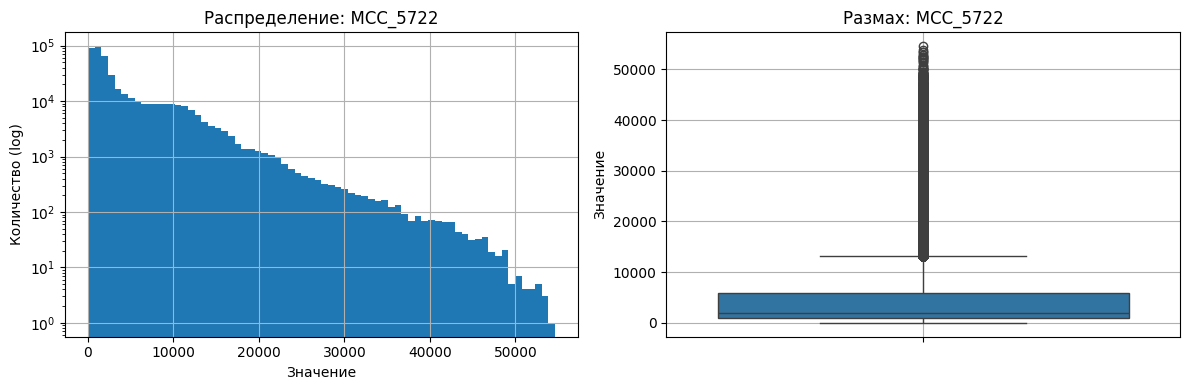

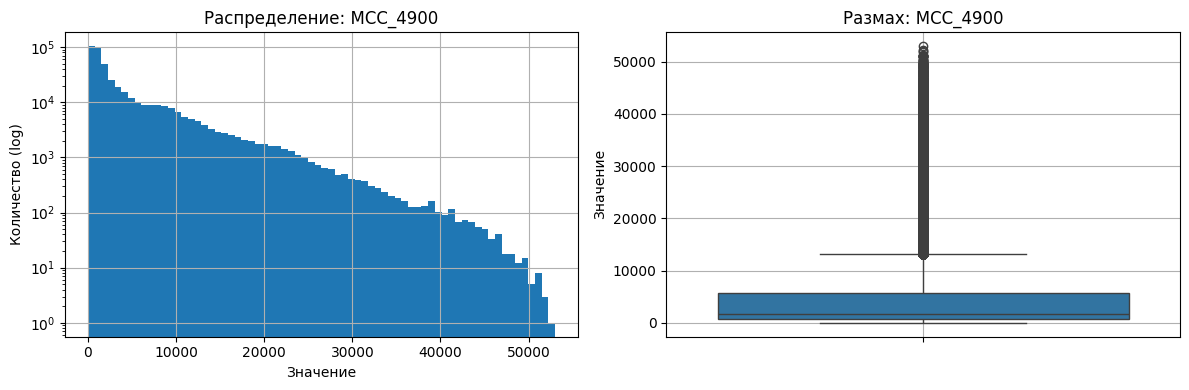

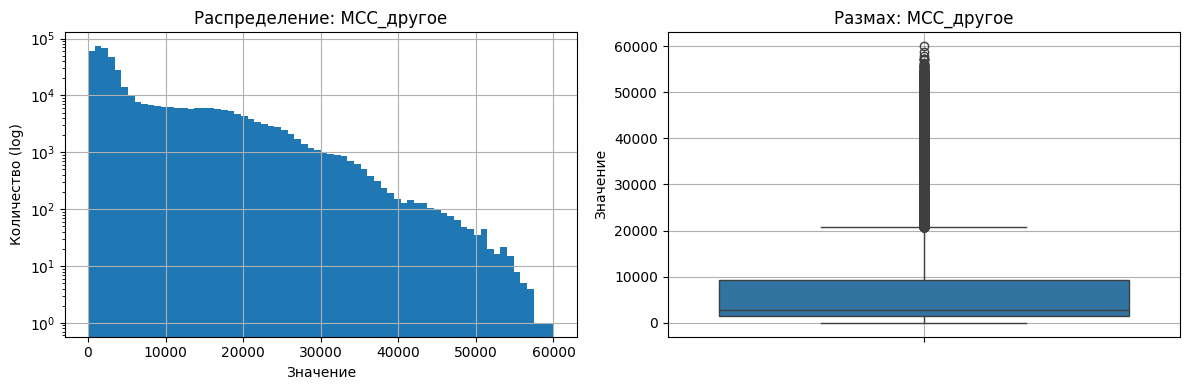

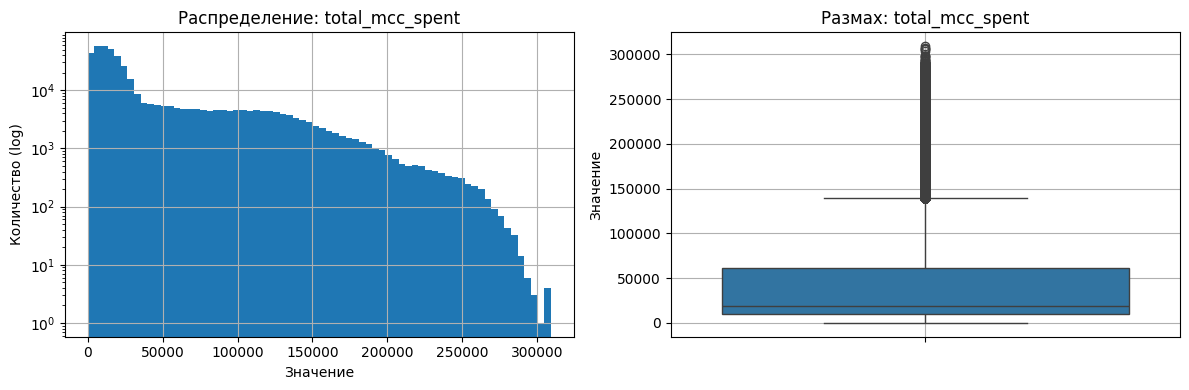

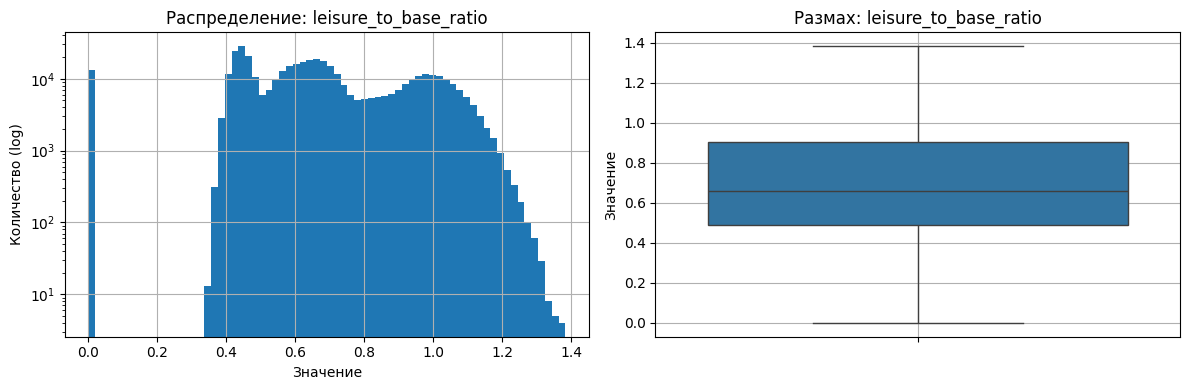

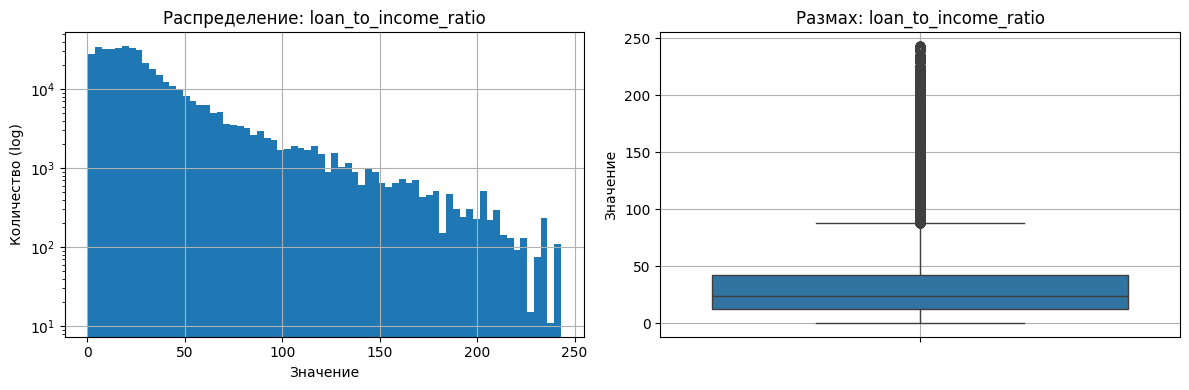

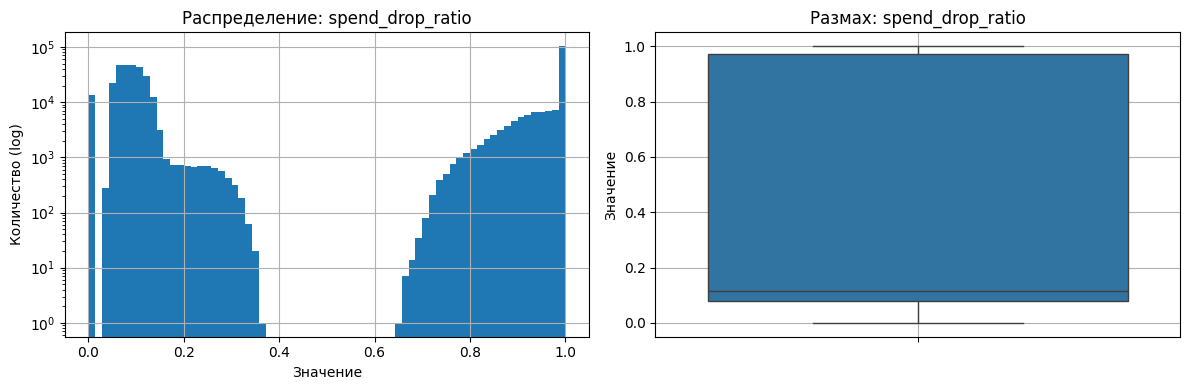

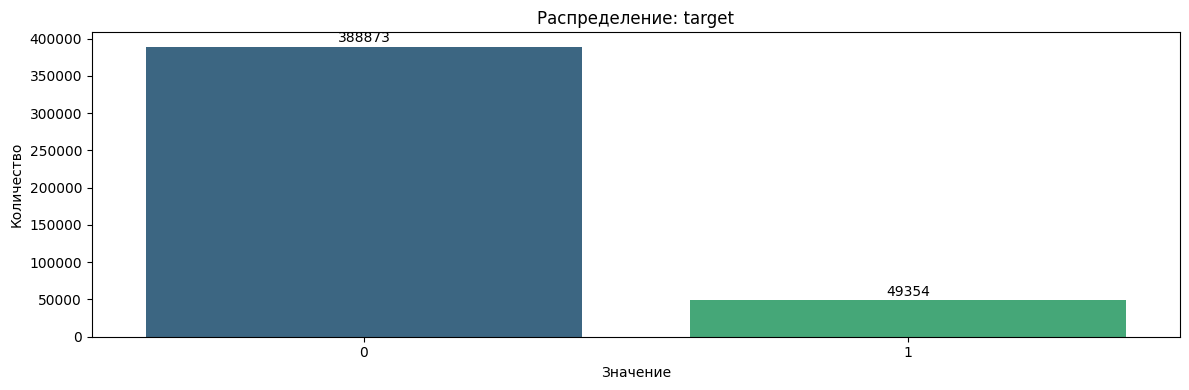

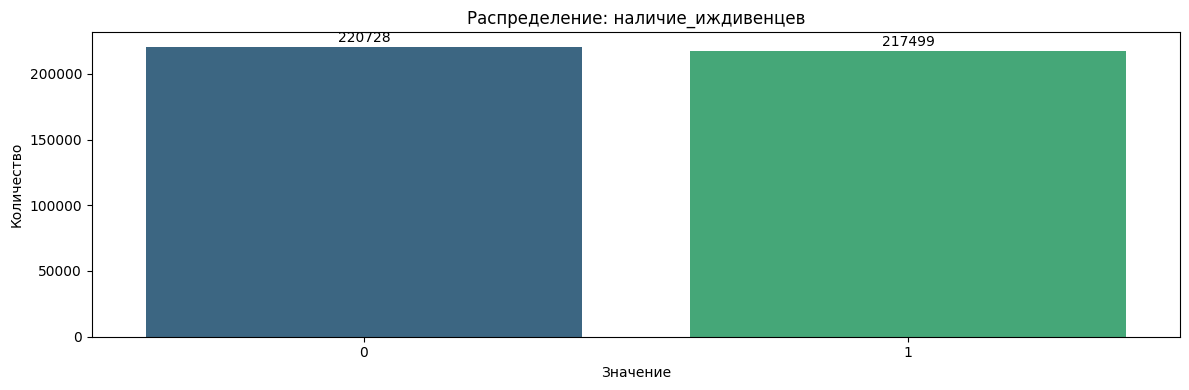

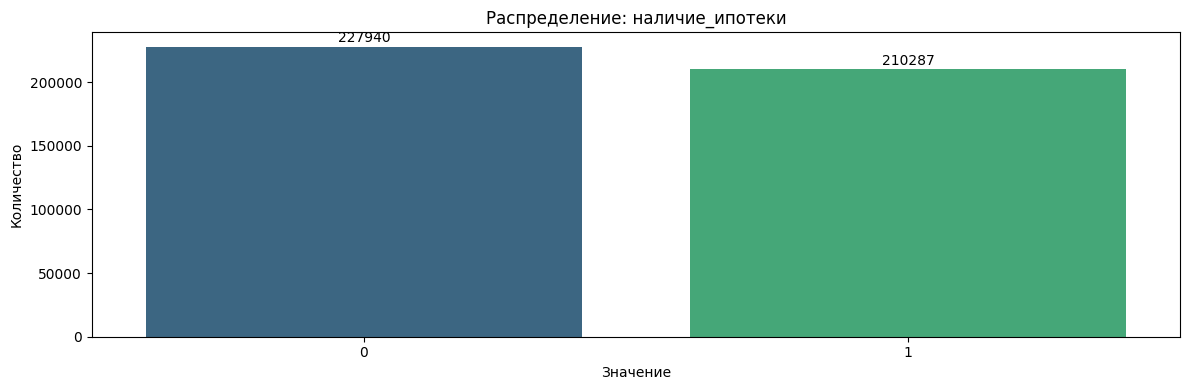

#### категориальные признаки

,семейное_положение
count,438227
unique,3
top,нет семьи
freq,146736


,Признак,Уникальные значения,Кол-во
0,семейное_положение,"[нет семьи, разведённые, есть семья]",3


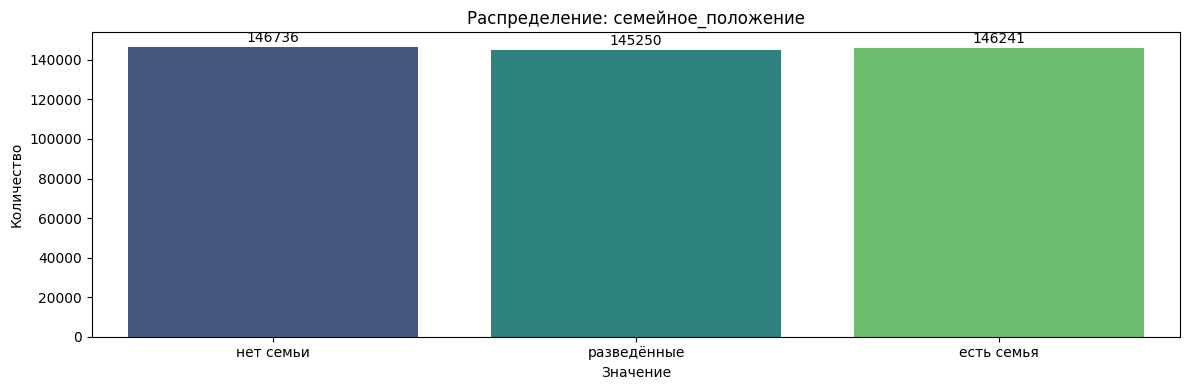

----------------------------------------------------------------------


In [23]:
primary_analysis(eda_df, 'Итоговый dataframe')

Анализ корреляций

In [24]:
def show_heatmap(corr, title, x, y_coef):
    num_rows = len(corr)
    dynamic_height = max(5, num_rows * y_coef)
    plt.figure(figsize=(x, dynamic_height))
    
    sns.heatmap(
        corr,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        linewidths=.5,
        cbar=False
    )
    
    plt.title(title)
    plt.show()

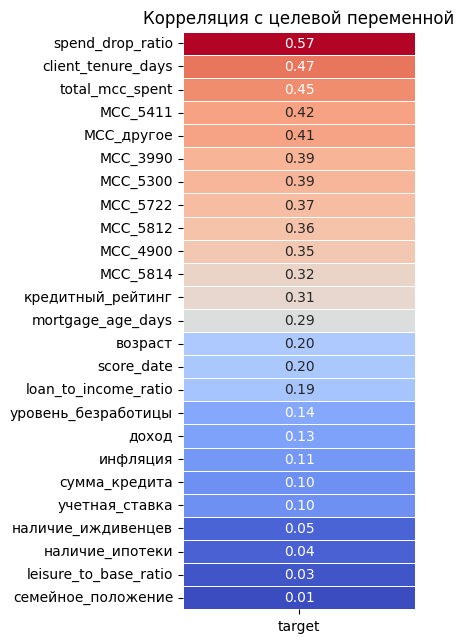

In [25]:
corr_matrix = eda_df.phik_matrix(njobs=-1, interval_cols=['target', 'возраст', 'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки', 'client_tenure_days', 'mortgage_age_days', 'учетная_ставка', 'уровень_безработицы', 'инфляция', 'кредитный_рейтинг', 'MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое', 'total_mcc_spent', 'leisure_to_base_ratio', 'loan_to_income_ratio', 'spend_drop_ratio'])
target_corr = corr_matrix[corr_matrix.index != 'target'][['target']].sort_values(by='target', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.3)

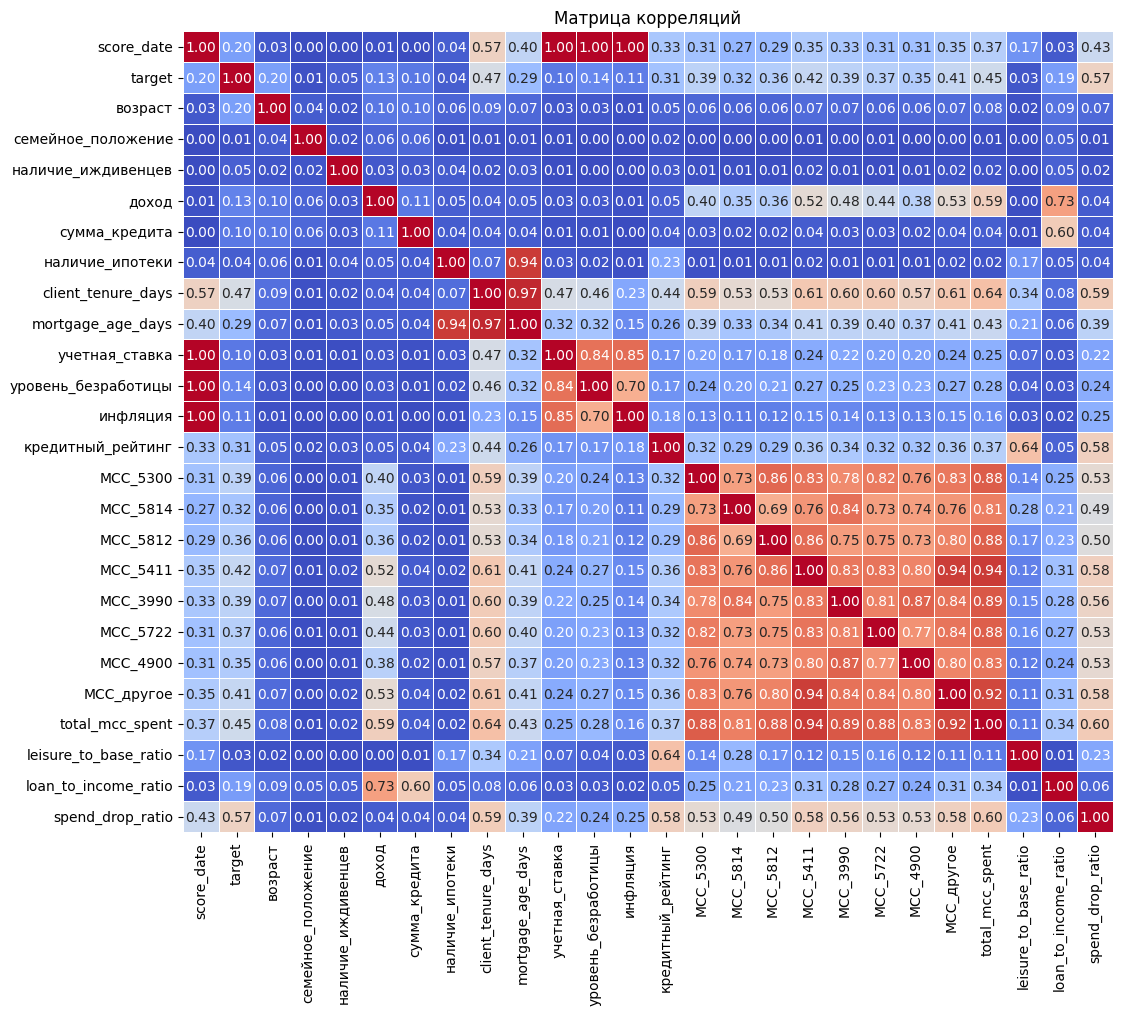

In [26]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=12, y_coef=.4)

Корреляции score_date и макропоказателей не будет при обучении, так как признак score_date нужен только для разделения на фолды, а после будет удален.

client_tenure_days и mortgage_age_days + наличие_ипотеки логически связаны, но несут разный смысл. Высокая корреляция (0.97) здесь объяснима - ипотека физически не может быть старше самого клиента в базе банка. Для моделей с градиентным расчетом ошибки стоит оставить то, что коррелирует меньше, но несет смысл разных признаков: client_tenure_days и наличие_ипотеки.

Показатели MCC_ имеют также высокую корреляцию, означающую, что более обеспеченные клиенты тратят во всех сегментах больше, чем остальные и наоборот. Значит, можно создать общий один признак, обозначающий траты до score_date.

In [27]:
def drop_problematic_columns(df):
    mcc_cols = [col for col in df.columns if 'MCC_' in col]
    cols_to_drop = ['инфляция', 'учетная_ставка', 'mortgage_age_days', *mcc_cols]

    return cols_to_drop

cols_to_drop = drop_problematic_columns(eda_df)
eda_df_no_multi = eda_df.drop(columns=cols_to_drop)

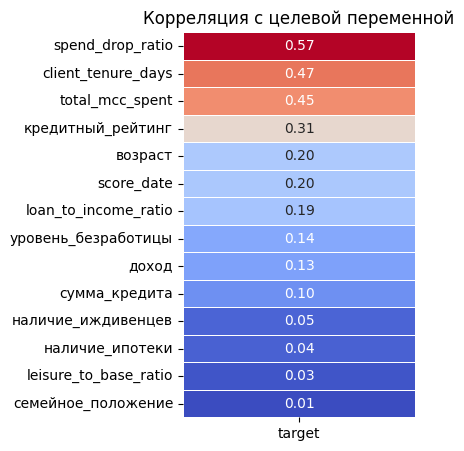

In [28]:
corr_matrix = eda_df_no_multi.phik_matrix(njobs=-1, interval_cols=['target', 'возраст', 'наличие_иждивенцев', 'доход', 'сумма_кредита', 'наличие_ипотеки', 'client_tenure_days', 'mortgage_age_days', 'уровень_безработицы', 'кредитный_рейтинг', 'total_mcc_spent', 'leisure_to_base_ratio', 'loan_to_income_ratio', 'spend_drop_ratio'])
target_corr = corr_matrix[corr_matrix.index != 'target'][['target']].sort_values(by='target', ascending=False)

show_heatmap(target_corr, title='Корреляция с целевой переменной', x=3, y_coef=.1)

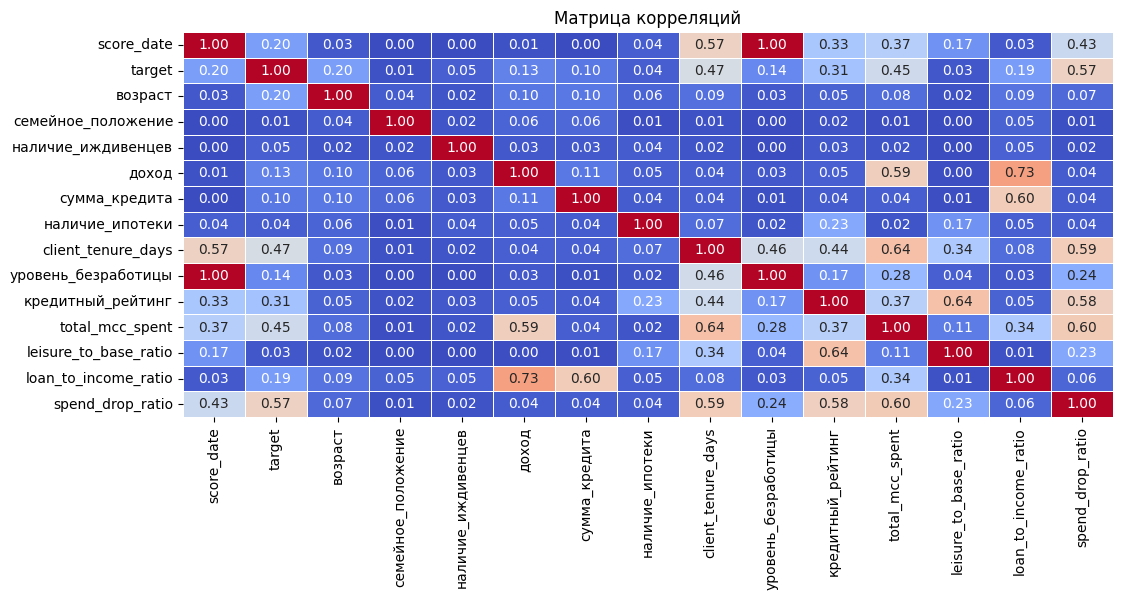

In [29]:
show_heatmap(corr_matrix, title='Матрица корреляций', x=12, y_coef=.3)

Выводы по EDA

После объединения 8 таблиц и фильтрации итоговый датасет содержит 438 227 строк, что на 24,12% меньше исходного объема; пропуски в данных отсутствуют. Единственный категориальный признак (семейное положение) сохранен из-за его логической значимости для оценки дефолта, несмотря на слабую корреляцию с таргетом. В данных наблюдается высокая мультиколлинеарность среди смысловых групп признаков, поэтому для обучения подготовлено два набора: один - для моделей, чувствительных к зависимости переменных (градиентный спуск), второй - для устойчивых к ней. Распределения трат по категориям имеют выраженные длинные хвосты, что требует логарифмирования в качестве дополнительной гипотезы. Целевая переменная характеризуется сильным дисбалансом классов в соотношении 89% к 11%.

## Моделирование

### ! КОММЕНТАРИЙ К РАБОТЕ
#### Не до конца понял мысль по 1200 строк для теста и валидации, почему выбрано именно такое число, учитывая кол-во данных в датасете? Буду рад пояснению.

В задаче сказано: "Вам нужно придерживаться описанной выше логики, используя горизонт прогнозирования 12 месяцев.". В материалах курса также об этом писалось: "Длина тестовой выборки должна быть как минимум равна горизонту прогнозирования — сколько шагов вперёд вы хотите предсказывать".

In [ ]:
df = df.sort_values('score_date').reset_index(drop=True)

max_date = df['score_date'].max()
test_threshold = max_date - pd.DateOffset(years=1)
calib_threshold = test_threshold - pd.DateOffset(years=1)

df_test = df[df['score_date'] >= test_threshold].copy()
df_calib = df[(df['score_date'] >= calib_threshold) & (df['score_date'] < test_threshold)].copy()
df_train = df[df['score_date'] < calib_threshold].copy()

print(f"Обучение: {df_train['score_date'].min().date()} - {df_train['score_date'].max().date()} | Строк: {len(df_train)}")
print(f"Калиброка: {df_calib['score_date'].min().date()} - {df_calib['score_date'].max().date()} | Строк: {len(df_calib)}")
print(f"Тест: {df_test['score_date'].min().date()} - {df_test['score_date'].max().date()} | Строк: {len(df_test)}")

gtss = GroupTimeSeriesSplit(n_splits=3, test_size=12)

groups = df_train['score_date']

X_train = df_train.drop(columns=['target'])
y_train = df_train['target']
print(f"Размер всего обучающего датасета: X_train={X_train.shape}; y_train={len(y_train)}")

X_calib = df_calib.drop(columns=['target'])
y_calib = df_calib['target']
print(f"Размер калибровки: X_calib={X_calib.shape}; y_calib={len(y_calib)}")

X_test = df_test.drop(columns=['target'])
y_test = df_test['target']
print(f"Размер теста: X_test={X_test.shape}; y_test={len(y_test)}")

Обучение: 2013-02-01 - 2017-11-01 | Строк: 233062
Калиброка: 2017-12-01 - 2018-11-01 | Строк: 93154
Тест: 2018-12-01 - 2019-12-01 | Строк: 112011
Размер всего обучающего датасета: X_train=(233062, 26); y_train=233062
Размер калибровки: X_calib=(93154, 26); y_calib=93154
Размер теста: X_test=(112011, 26); y_test=112011


In [31]:
useless_cols = ['ID', 'score_date']

num_cols = [col for col in X_train.select_dtypes(include=['number']).columns if col not in useless_cols]
cat_cols = [col for col in X_train.select_dtypes(include=['str']).columns if col not in useless_cols]

problems_cols = drop_problematic_columns(X_train)
num_cols_without_problems = [col for col in num_cols if col not in problems_cols]
cat_cols_without_problems = [col for col in cat_cols if col not in problems_cols]

In [32]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_without_problems),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols_without_problems),
    ],
    remainder='drop'
).set_output(transform="pandas")

tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols),
        ('num', 'passthrough', num_cols),
    ],
    remainder='drop',
).set_output(transform="pandas")

In [33]:
X_transformed_df = linear_preprocessor.fit_transform(X_train)
X_transformed_df.head()

,num__возраст,num__наличие_иждивенцев,num__доход,num__сумма_кредита,num__наличие_ипотеки,num__client_tenure_days,num__уровень_безработицы,num__кредитный_рейтинг,num__total_mcc_spent,num__leisure_to_base_ratio,num__loan_to_income_ratio,num__spend_drop_ratio,cat__семейное_положение_нет семьи,cat__семейное_положение_разведённые
0,1.474897,-0.988507,0.415168,0.418462,-0.944692,-1.250755,1.154201,-4.311604,-0.984354,-2.653744,-0.302060,-1.251564,1.0,0.0
1,-0.367537,-0.988507,1.469375,-0.896742,-0.944692,-1.250755,1.154201,-4.311604,-0.984354,-2.653744,-0.786250,-1.251564,0.0,1.0
2,0.816885,1.011627,1.437761,0.796410,-0.944692,-1.175508,1.154201,0.013885,0.962299,-1.006975,-0.423997,1.022418,0.0,1.0
3,1.277493,1.011627,-0.815094,1.492627,-0.944692,-1.250755,1.154201,-4.311604,-0.984354,-2.653744,1.066038,-1.251564,1.0,0.0
4,-0.235934,-0.988507,0.217844,1.154578,1.058546,-1.175508,1.154201,0.457892,0.574413,-0.967868,0.001264,1.022418,1.0,0.0


In [34]:
X_transformed_df = tree_preprocessor.fit_transform(X_train)
X_transformed_df.head()

,cat__семейное_положение_нет семьи,cat__семейное_положение_разведённые,num__возраст,num__наличие_иждивенцев,num__доход,num__сумма_кредита,num__наличие_ипотеки,num__client_tenure_days,num__mortgage_age_days,num__учетная_ставка,num__уровень_безработицы,num__инфляция,num__кредитный_рейтинг,num__MCC_5300,num__MCC_5814,num__MCC_5812,num__MCC_5411,num__MCC_3990,num__MCC_5722,num__MCC_4900,num__MCC_другое,num__total_mcc_spent,num__leisure_to_base_ratio,num__loan_to_income_ratio,num__spend_drop_ratio
0,1.0,0.0,65,0,96507,2391435,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,24.779912,0.0
1,0.0,1.0,37,0,138590,992115,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,7.158633,0.0
2,0.0,1.0,55,1,137328,2793555,0,31,-1.0,5.5,5.7,0.97,603.0,15112.35,5801.92,6434.77,28938.90,2959.570068,10244.07,18173.74,16595.48,104260.800068,0.422846,20.342210,1.0
3,1.0,0.0,62,1,47396,3534300,0,0,-1.0,5.5,5.7,0.97,-1.0,0.00,0.00,0.00,0.00,0.000000,0.00,0.00,0.00,0.000000,0.000000,74.569584,0.0
4,1.0,0.0,39,0,88630,3174630,1,31,31.0,5.5,5.7,0.97,665.0,13197.14,4496.55,5001.23,21940.53,2424.159912,8892.09,14706.82,12827.45,83485.969912,0.432887,35.818910,1.0


In [35]:
def get_approval_rate(fn, tn, n):
    return (fn + tn) / n

def get_default_rate(fn, tn):
    return fn / (fn + tn)

def get_missed_defaults_rate(fn, tp):
    return fn / (fn + tp)

In [36]:
results = []

### ! КОММЕНТАРИЙ К РАБОТЕ

Были разные идеи как реализовать evaluate_model (функцию ниже) для кросс валидации. Использовал усреднение метрик со стандартным порогом 0.5. При дисбалансе классов это очевидный риск, но полноценная калибровка модели требует дополнительных данных, а при выборке всего в 6 лет (где шаг теста и калибровки равен году, по условию задачи) это сильно сокращает объем обучения. В итоге решил оставить базовый порог, но опасаюсь, что логистическая регрессия может неоправданно проиграть более дорогому бустингу или бэггингу только из-за отсутствия подбора порога, даже если данные линейно-разделимы. Подскажите, верна ли такая логика и есть ли здесь более правильное решение?

In [37]:
def evaluate_model(pipeline, X_train, y_train, groups, name="Model"):
    scores = []
    for train_idx, val_idx in gtss.split(X_train, y_train, groups=groups):
        X_local_train, X_local_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_local_train, y_local_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipeline.fit(X_local_train, y_local_train)
        
        y_pred = pipeline.predict(X_local_val)
        y_proba = pipeline.predict_proba(X_local_val)[:, 1]

        roc_auc = roc_auc_score(y_local_val, y_proba)
    
        tn, _, fn, tp = confusion_matrix(y_local_val, y_pred).ravel()
        approval_rate = get_approval_rate(fn, tn, len(y_local_val))
        default_rate = get_default_rate(fn, tn)
        missed_defaults_rate = get_missed_defaults_rate(fn, tp)

        metrics = {
            "roc_auc": roc_auc,
            "approval_rate": approval_rate,
            "default_rate": default_rate,
            "missed_defaults_rate": missed_defaults_rate
        }

        display(pd.DataFrame([metrics]))
        scores.append(metrics)

    scores_df = pd.DataFrame(scores)
    
    metrics = {
        'Название модели': name,
        "roc_auc": scores_df["roc_auc"].mean(),
        "approval_rate": scores_df["approval_rate"].mean(),
        "default_rate": scores_df["default_rate"].mean(),
        "missed_defaults_rate": scores_df["missed_defaults_rate"].mean()
    }
    print("Итоговые усредненные метрики:")
    display(pd.DataFrame([metrics]))
    
    results.append(metrics)

In [38]:
def run_optuna(build_pipeline_fn, build_best_pipeline_fn, name, n_trials=10):
    def objective(trial):
        pipeline = build_pipeline_fn(trial)

        scores = []
        for train_idx, val_idx in gtss.split(X_train, y_train, groups=groups):
            X_local_train, X_local_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_local_train, y_local_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            pipeline.fit(X_local_train, y_local_train)
            
            y_pred = pipeline.predict(X_local_val)

            tn, _, fn, tp = confusion_matrix(y_local_val, y_pred).ravel()
            approval_rate = get_approval_rate(fn, tn, len(y_local_val))
            default_rate = get_default_rate(fn, tn)
            missed_defaults_rate = get_missed_defaults_rate(fn, tp)
            
            scores.append({
                'approval_rate': approval_rate, 
                'default_rate': default_rate, 
                'missed_defaults_rate': missed_defaults_rate
            })
            
        df_scores = pd.DataFrame(scores)
        return (
            float(df_scores['approval_rate'].mean()), 
            float(df_scores['default_rate'].mean()), 
            float(df_scores['missed_defaults_rate'].mean())
        )

    sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
    study = optuna.create_study(directions=['maximize', 'minimize', 'minimize'], sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True, n_jobs=4)

    fig1 = optuna.visualization.plot_optimization_history(
        study, target=lambda t: t.values[2], target_name="missed_defaults_rate"
    )
    fig2 = optuna.visualization.plot_param_importances(
        study, target=lambda t: t.values[2], target_name="missed_defaults_rate"
    )
    display(fig1)
    display(fig2)
    
    best_trial = min(study.best_trials, key=lambda t: t.values[2])
    
    best_params = best_trial.params
    print("Лучшие гиперпараметры:", best_params)
    print("Лучшее среднее значение Missed Defaults Rate на кросс-валидации:", best_trial.values)

    evaluate_model(build_best_pipeline_fn(best_params), X_train, y_train, groups, name=name)

    return best_params

In [39]:
def get_base_pipeline(preprocessor, model):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
def get_ros_pipeline(preprocessor, model):
    return ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('over', RandomOverSampler(random_state=RANDOM_STATE)),
        ('model', model)
    ])
    
def get_smote_pipeline(preprocessor, model):
    return ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('model', model)
    ])
    
# def get_rus_pipeline(preprocessor, model):
#     return ImbPipeline(steps=[
#         ('preprocessor', preprocessor),
#         ('smote', RandomUnderSampler(random_state=RANDOM_STATE)),
#         ('model', model)
#     ])
    
# def get_cc_pipeline(preprocessor, model):
#     return ImbPipeline(steps=[
#         ('preprocessor', preprocessor),
#         ('cluster', ClusterCentroids(random_state=RANDOM_STATE)),
#         ('model', model)
#     ])

In [40]:
def get_linear_params(trial):
    params = {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "fit_intercept": True,
        "tol": trial.suggest_float("tol", 1e-4, 1e-2, log=True),
        "max_iter": trial.suggest_int("max_iter", 2000, 20000),
        "solver": trial.suggest_categorical("solver", ["lbfgs", "newton-cg", "newton-cholesky", "saga"]),
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "random_state": RANDOM_STATE,
    }

    solver = params["solver"]
    if solver in ["lbfgs", "newton-cg", "newton-cholesky"]:
        params["l1_ratio"] = 0
    elif solver == "saga":
        params["l1_ratio"] = trial.suggest_float("l1_ratio", 0.0, 1.0)
    
    return params

def build_pipeline_fn(trial):
    model = LogisticRegression(**get_linear_params(trial))
    return get_base_pipeline(linear_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
    return get_base_pipeline(linear_preprocessor, model)

lr_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression")

def build_pipeline_fn(trial):
    model = LogisticRegression(**get_linear_params(trial))
    return get_ros_pipeline(linear_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
    return get_ros_pipeline(linear_preprocessor, model)

lr_os_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression with Over Sampler")

def build_pipeline_fn(trial):
    model = LogisticRegression(**get_linear_params(trial))
    return get_smote_pipeline(linear_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
    return get_smote_pipeline(linear_preprocessor, model)

lr_smote_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression with SMOTE")

# def build_pipeline_fn(trial):
#     model = LogisticRegression(**get_linear_params(trial))
#     return get_rus_pipeline(linear_preprocessor, model)

# def build_best_pipeline_fn(best_params):
#     model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
#     return get_rus_pipeline(linear_preprocessor, model)

# lr_us_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression with Under Sampler")

# def build_pipeline_fn(trial):
#     model = LogisticRegression(**get_linear_params(trial))
#     return get_cc_pipeline(linear_preprocessor, model)

# def build_best_pipeline_fn(best_params):
#     model = LogisticRegression(**best_params, random_state=RANDOM_STATE)
#     return get_cc_pipeline(linear_preprocessor, model)

# lr_cc_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Logistic Regression with Cluster Centroids")

[I 2026-02-25 01:19:16,801] A new study created in memory with name: no-name-24691529-4619-4fc1-bb2a-6b00524340a2
 20%|██        | 2/10 [00:00<00:03,  2.38it/s]

[I 2026-02-25 01:19:17,591] Trial 0 finished with values: [0.9717213878883206, 0.08978988492122723, 0.8618283136085273] and parameters: {'class_weight': None, 'tol': 0.00599970741532738, 'max_iter': 13287, 'solver': 'newton-cg', 'C': 1.9644008930246226}.
[I 2026-02-25 01:19:17,751] Trial 3 finished with values: [0.7317924440423521, 0.021927232325234292, 0.1584699477854414] and parameters: {'class_weight': 'balanced', 'tol': 0.0010681964654934485, 'max_iter': 12010, 'solver': 'lbfgs', 'C': 0.49311022629847523}.


 30%|███       | 3/10 [00:01<00:02,  2.45it/s]

[I 2026-02-25 01:19:18,148] Trial 4 finished with values: [0.9702894146514215, 0.08919888849795006, 0.8549164468968717] and parameters: {'class_weight': None, 'tol': 0.0002349928820336048, 'max_iter': 8205, 'solver': 'newton-cg', 'C': 82.45723222486399}.


 50%|█████     | 5/10 [00:01<00:01,  3.26it/s]

[I 2026-02-25 01:19:18,520] Trial 6 finished with values: [0.7302610806349348, 0.02112598022502013, 0.15237916140864108] and parameters: {'class_weight': 'balanced', 'tol': 0.007901850600712471, 'max_iter': 12144, 'solver': 'lbfgs', 'C': 3.4286658971769315}.
[I 2026-02-25 01:19:18,664] Trial 1 finished with values: [0.985930674633449, 0.09519147014073397, 0.9270795439186287] and parameters: {'class_weight': None, 'tol': 0.0018958336500010807, 'max_iter': 10651, 'solver': 'saga', 'C': 0.0007107363172233553, 'l1_ratio': 0.12930488402156282}.


 80%|████████  | 8/10 [00:02<00:00,  3.96it/s]

[I 2026-02-25 01:19:19,016] Trial 7 finished with values: [0.9708551407769974, 0.08943145370096289, 0.8576274362659634] and parameters: {'class_weight': None, 'tol': 0.000575204240271677, 'max_iter': 17449, 'solver': 'newton-cholesky', 'C': 0.2003708986763844}.
[I 2026-02-25 01:19:19,093] Trial 2 finished with values: [0.9707473890306222, 0.08938364182747659, 0.8570724510634244] and parameters: {'class_weight': None, 'tol': 0.00017540444994095222, 'max_iter': 12970, 'solver': 'saga', 'C': 94.67685568473559, 'l1_ratio': 0.7298801328397254}.
[I 2026-02-25 01:19:19,131] Trial 8 finished with values: [0.7124286515682905, 0.01782890473344727, 0.12549094497744004] and parameters: {'class_weight': 'balanced', 'tol': 0.008321180223717875, 'max_iter': 18154, 'solver': 'newton-cholesky', 'C': 0.0001353273515288106}.
[I 2026-02-25 01:19:19,145] Trial 5 finished with values: [0.9927704001041486, 0.09807413685397091, 0.9617398742307244] and parameters: {'class_weight': None, 'tol': 0.00316361056837

100%|██████████| 10/10 [00:02<00:00,  3.93it/s]


[I 2026-02-25 01:19:19,347] Trial 9 finished with values: [0.9865267353517021, 0.09537668864778785, 0.9293969872719173] and parameters: {'class_weight': None, 'tol': 0.0017084781687713535, 'max_iter': 16498, 'solver': 'newton-cg', 'C': 0.0005615349374672627}.


Лучшие гиперпараметры: {'class_weight': 'balanced', 'tol': 0.008321180223717875, 'max_iter': 18154, 'solver': 'newton-cholesky', 'C': 0.0001353273515288106}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.7124286515682905, 0.01782890473344727, 0.12549094497744004]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.890877,0.713265,0.019127,0.133583


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.892484,0.714865,0.018343,0.129692


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.894422,0.716644,0.017684,0.12613


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Logistic Regression,0.892594,0.714925,0.018385,0.129801


[I 2026-02-25 01:19:20,211] A new study created in memory with name: no-name-7b867527-8431-4fbf-baa4-7efc7e80f652
 20%|██        | 2/10 [00:01<00:04,  1.99it/s]

[I 2026-02-25 01:19:21,223] Trial 2 finished with values: [0.7328146864145507, 0.022307313815090598, 0.16143052958469464] and parameters: {'class_weight': None, 'tol': 0.0005060434458066376, 'max_iter': 19149, 'solver': 'newton-cholesky', 'C': 0.060860755215175914}.
[I 2026-02-25 01:19:21,366] Trial 1 finished with values: [0.7342126234816, 0.02262405483826904, 0.16412001639740617] and parameters: {'class_weight': 'balanced', 'tol': 0.0006969675329055498, 'max_iter': 16270, 'solver': 'newton-cholesky', 'C': 14.578727815767913}.


 30%|███       | 3/10 [00:01<00:02,  2.99it/s]

[I 2026-02-25 01:19:21,502] Trial 0 finished with values: [0.7261186132732709, 0.02034197446808191, 0.14596784134880605] and parameters: {'class_weight': 'balanced', 'tol': 0.0003873817076979756, 'max_iter': 6399, 'solver': 'lbfgs', 'C': 0.00025470708634569466}.


 40%|████      | 4/10 [00:01<00:02,  2.38it/s]

[I 2026-02-25 01:19:22,056] Trial 6 finished with values: [0.735171382465988, 0.022214673041239336, 0.16129074887397252] and parameters: {'class_weight': None, 'tol': 0.004467652472606069, 'max_iter': 14549, 'solver': 'lbfgs', 'C': 18.857523352057687}.


 60%|██████    | 6/10 [00:02<00:01,  3.55it/s]

[I 2026-02-25 01:19:22,284] Trial 5 finished with values: [0.7353625976633746, 0.022418275330478448, 0.16290732271640293] and parameters: {'class_weight': 'balanced', 'tol': 0.005010791345804145, 'max_iter': 2360, 'solver': 'newton-cg', 'C': 40.54249164806244}.
[I 2026-02-25 01:19:22,430] Trial 4 finished with values: [0.7335993859522688, 0.022269766136904668, 0.16142131465389234] and parameters: {'class_weight': 'balanced', 'tol': 0.0006809239177864421, 'max_iter': 17650, 'solver': 'newton-cg', 'C': 0.0048047723560219885}.


 70%|███████   | 7/10 [00:02<00:00,  3.21it/s]

[I 2026-02-25 01:19:22,805] Trial 7 finished with values: [0.7312247220180214, 0.021671256813077206, 0.15650539311075493] and parameters: {'class_weight': None, 'tol': 0.00018637753684921937, 'max_iter': 14923, 'solver': 'lbfgs', 'C': 0.0010177143024810548}.


 80%|████████  | 8/10 [00:02<00:00,  3.01it/s]

[I 2026-02-25 01:19:23,181] Trial 3 finished with values: [0.7313264596270704, 0.02192615826672026, 0.15844268004157055] and parameters: {'class_weight': 'balanced', 'tol': 0.0042953455117901865, 'max_iter': 3200, 'solver': 'saga', 'C': 0.04195512080549562, 'l1_ratio': 0.10246082688935298}.


 90%|█████████ | 9/10 [00:04<00:00,  1.73it/s]

[I 2026-02-25 01:19:24,301] Trial 9 finished with values: [0.7198603926394901, 0.018682967324196557, 0.13288622022336272] and parameters: {'class_weight': None, 'tol': 0.003635165462503525, 'max_iter': 19621, 'solver': 'saga', 'C': 0.0002984825905728109, 'l1_ratio': 0.19886408265942757}.


100%|██████████| 10/10 [00:04<00:00,  2.27it/s]

[I 2026-02-25 01:19:24,621] Trial 8 finished with values: [0.7299718954496334, 0.021616159798147756, 0.15584424453148574] and parameters: {'class_weight': None, 'tol': 0.0013574291088535905, 'max_iter': 12269, 'solver': 'saga', 'C': 16.308018022309316, 'l1_ratio': 0.42297797901289114}.


Лучшие гиперпараметры: {'class_weight': None, 'tol': 0.003635165462503525, 'max_iter': 19621, 'solver': 'saga', 'C': 0.0002984825905728109, 'l1_ratio': 0.19886408265942757}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.7198603926394901, 0.018682967324196557, 0.13288622022336272]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.892902,0.721123,0.020146,0.142248


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.894401,0.722572,0.019137,0.136761


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.896098,0.724471,0.018729,0.135039


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Logistic Regression with Over Sampler,0.894467,0.722722,0.019337,0.138016


[I 2026-02-25 01:19:26,385] A new study created in memory with name: no-name-3028ac96-e38e-4922-945e-7af98dd008ab
 10%|█         | 1/10 [00:03<00:27,  3.11s/it]

[I 2026-02-25 01:19:29,488] Trial 3 finished with values: [0.7334359162571649, 0.022358652622246494, 0.16194251040291463] and parameters: {'class_weight': 'balanced', 'tol': 0.002917099147169971, 'max_iter': 19424, 'solver': 'newton-cholesky', 'C': 13.047663001583071}.


 20%|██        | 2/10 [00:03<00:11,  1.40s/it]

[I 2026-02-25 01:19:29,691] Trial 0 finished with values: [0.733769086061354, 0.021969516557357516, 0.15922533360198252] and parameters: {'class_weight': 'balanced', 'tol': 0.002751942819577827, 'max_iter': 14859, 'solver': 'newton-cg', 'C': 0.9915271446779156}.


 30%|███       | 3/10 [00:04<00:09,  1.36s/it]

[I 2026-02-25 01:19:31,008] Trial 1 finished with values: [0.7329894880060778, 0.022373909639342493, 0.16202309942965856] and parameters: {'class_weight': None, 'tol': 0.002384048318413563, 'max_iter': 7157, 'solver': 'saga', 'C': 38.04839436591009, 'l1_ratio': 0.6701045944528212}.


 40%|████      | 4/10 [00:05<00:06,  1.09s/it]

[I 2026-02-25 01:19:31,678] Trial 2 finished with values: [0.7344397221741169, 0.02272146100484465, 0.16483457186941178] and parameters: {'class_weight': None, 'tol': 0.00031261961232909626, 'max_iter': 12571, 'solver': 'saga', 'C': 0.3245423194652377, 'l1_ratio': 0.745852206470027}.


 60%|██████    | 6/10 [00:06<00:02,  1.50it/s]

[I 2026-02-25 01:19:32,306] Trial 4 finished with values: [0.7343202582443236, 0.02263111218659847, 0.16423678680186124] and parameters: {'class_weight': 'balanced', 'tol': 0.0006702917874768422, 'max_iter': 10664, 'solver': 'newton-cholesky', 'C': 6.505994624009307}.
[I 2026-02-25 01:19:32,483] Trial 5 finished with values: [0.7335434206215545, 0.02245507311500876, 0.16277648672980105] and parameters: {'class_weight': 'balanced', 'tol': 0.00855059644538175, 'max_iter': 19072, 'solver': 'newton-cholesky', 'C': 7.765893359985382}.


 70%|███████   | 7/10 [00:07<00:02,  1.14it/s]

[I 2026-02-25 01:19:33,799] Trial 6 finished with values: [0.7371377300916165, 0.023250484047893923, 0.16928010763465573] and parameters: {'class_weight': None, 'tol': 0.00038054255737935154, 'max_iter': 19347, 'solver': 'newton-cholesky', 'C': 1.0302201715188226}.


 80%|████████  | 8/10 [00:09<00:02,  1.15s/it]

[I 2026-02-25 01:19:35,533] Trial 7 finished with values: [0.7160204062097986, 0.01813292874698229, 0.1283002757771923] and parameters: {'class_weight': 'balanced', 'tol': 0.00758987257915987, 'max_iter': 9626, 'solver': 'saga', 'C': 0.00040801785514401034, 'l1_ratio': 0.7374914378780577}.


100%|██████████| 10/10 [00:10<00:00,  1.09s/it]

[I 2026-02-25 01:19:37,225] Trial 8 finished with values: [0.7316974701493709, 0.022109019280748692, 0.15977887349751804] and parameters: {'class_weight': None, 'tol': 0.0005139289413196438, 'max_iter': 2068, 'solver': 'saga', 'C': 0.23925035473600165, 'l1_ratio': 0.14386514883564472}.
[I 2026-02-25 01:19:37,281] Trial 9 finished with values: [0.7306177272690882, 0.021648584627648692, 0.156224650509711] and parameters: {'class_weight': None, 'tol': 0.0006912280755056436, 'max_iter': 2181, 'solver': 'saga', 'C': 0.004349567460775975, 'l1_ratio': 0.06155943034302436}.


Лучшие гиперпараметры: {'class_weight': 'balanced', 'tol': 0.00758987257915987, 'max_iter': 9626, 'solver': 'saga', 'C': 0.00040801785514401034, 'l1_ratio': 0.7374914378780577}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.7160204062097986, 0.01813292874698229, 0.1283002757771923]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.892223,0.716923,0.019545,0.137204


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.89379,0.717724,0.018524,0.131491


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.895701,0.721734,0.018393,0.132111


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Logistic Regression with SMOTE,0.893905,0.718794,0.018821,0.133602


In [41]:
def get_decision_tree_params(trial):
    return {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "criterion": trial.suggest_categorical("criterion", ["entropy", "log_loss"]),
        "splitter": "best",
        "max_depth": trial.suggest_int("max_depth", 4, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 10, 60),
        "min_samples_split": trial.suggest_int("min_samples_split", 20, 150),
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-5, 2e-3, log=True),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-5, 5e-3, log=True),
        "random_state": RANDOM_STATE,
    }

def build_pipeline_fn(trial):
    model = DecisionTreeClassifier(**get_decision_tree_params(trial))
    return get_base_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
    return get_base_pipeline(tree_preprocessor, model)

dt_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier")

def build_pipeline_fn(trial):
    model = DecisionTreeClassifier(**get_decision_tree_params(trial))
    return get_ros_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
    return get_ros_pipeline(tree_preprocessor, model)

dt_os_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier with Over Sampler")

def build_pipeline_fn(trial):
    model = DecisionTreeClassifier(**get_decision_tree_params(trial))
    return get_smote_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
    return get_smote_pipeline(tree_preprocessor, model)

dt_smote_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier with SMOTE")

# def build_pipeline_fn(trial):
#     model = DecisionTreeClassifier(**get_decision_tree_params(trial))
#     return get_rus_pipeline(tree_preprocessor, model)

# def build_best_pipeline_fn(best_params):
#     model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
#     return get_rus_pipeline(tree_preprocessor, model)

# dt_us_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier with Under Sampler")

# def build_pipeline_fn(trial):
#     model = DecisionTreeClassifier(**get_decision_tree_params(trial))
#     return get_cc_pipeline(tree_preprocessor, model)

# def build_best_pipeline_fn(best_params):
#     model = DecisionTreeClassifier(**best_params, random_state=RANDOM_STATE)
#     return get_cc_pipeline(tree_preprocessor, model)

# dt_cc_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Decision Tree Classifier with Cluster Centroids")

[I 2026-02-25 01:19:41,114] A new study created in memory with name: no-name-58e70df9-e970-420a-97bc-b24af4330bfd
 10%|█         | 1/10 [00:02<00:25,  2.81s/it]

[I 2026-02-25 01:19:43,920] Trial 3 finished with values: [0.6862830619563552, 0.01207299644510195, 0.08185103852592392] and parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 27, 'min_samples_split': 41, 'min_impurity_decrease': 8.223328340400518e-05, 'ccp_alpha': 0.0033092343443583898}.


 20%|██        | 2/10 [00:03<00:13,  1.73s/it]

[I 2026-02-25 01:19:44,905] Trial 1 finished with values: [0.7509773459811102, 0.02265728748477953, 0.16812812958740878] and parameters: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 8, 'min_samples_leaf': 51, 'min_samples_split': 77, 'min_impurity_decrease': 1.4899609381593706e-05, 'ccp_alpha': 0.0004986972526642003}.


 40%|████      | 4/10 [00:04<00:04,  1.37it/s]

[I 2026-02-25 01:19:45,332] Trial 2 finished with values: [0.6951284698042568, 0.013871527315316092, 0.09572401803464226] and parameters: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 9, 'min_samples_leaf': 47, 'min_samples_split': 128, 'min_impurity_decrease': 6.572338446361854e-05, 'ccp_alpha': 0.002206869748839997}.
[I 2026-02-25 01:19:45,440] Trial 0 finished with values: [0.9750512065601291, 0.08938157807006664, 0.860892186249789] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 16, 'min_samples_split': 133, 'min_impurity_decrease': 2.350277932268865e-05, 'ccp_alpha': 0.00016521204710536893}.


 50%|█████     | 5/10 [00:05<00:05,  1.00s/it]

[I 2026-02-25 01:19:46,925] Trial 4 finished with values: [0.9754893336445796, 0.08897927371263577, 0.8573680655749912] and parameters: {'class_weight': None, 'criterion': 'log_loss', 'max_depth': 7, 'min_samples_leaf': 60, 'min_samples_split': 74, 'min_impurity_decrease': 0.0003646403585138557, 'ccp_alpha': 3.342398663371405e-05}.


 60%|██████    | 6/10 [00:06<00:04,  1.00s/it]

[I 2026-02-25 01:19:47,932] Trial 6 finished with values: [0.9877866270604811, 0.0945521703285227, 0.9225443348421467] and parameters: {'class_weight': None, 'criterion': 'log_loss', 'max_depth': 13, 'min_samples_leaf': 45, 'min_samples_split': 125, 'min_impurity_decrease': 0.0012224702449196419, 'ccp_alpha': 0.0011465323858885304}.


 70%|███████   | 7/10 [00:07<00:02,  1.16it/s]

[I 2026-02-25 01:19:48,494] Trial 7 finished with values: [1.0, 0.10123946390952611, 1.0] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 38, 'min_samples_split': 132, 'min_impurity_decrease': 0.0003554391741368296, 'ccp_alpha': 0.004188880434318553}.


 80%|████████  | 8/10 [00:08<00:01,  1.26it/s]

[I 2026-02-25 01:19:49,143] Trial 5 finished with values: [0.9640166698178047, 0.08616212356412016, 0.820505266529362] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 35, 'min_samples_split': 65, 'min_impurity_decrease': 9.490983870154064e-05, 'ccp_alpha': 0.0002018323594861887}.


 90%|█████████ | 9/10 [00:08<00:00,  1.24it/s]

[I 2026-02-25 01:19:49,989] Trial 8 finished with values: [0.9754893336445796, 0.08897927371263577, 0.8573680655749912] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 13, 'min_samples_leaf': 14, 'min_samples_split': 107, 'min_impurity_decrease': 0.00039267244102787963, 'ccp_alpha': 9.807550120022096e-05}.


100%|██████████| 10/10 [00:09<00:00,  1.03it/s]

[I 2026-02-25 01:19:50,780] Trial 9 finished with values: [0.9877866270604811, 0.0945521703285227, 0.9225443348421467] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 37, 'min_samples_split': 121, 'min_impurity_decrease': 0.0004678078816578421, 'ccp_alpha': 0.0007983891334344153}.


Лучшие гиперпараметры: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 27, 'min_samples_split': 41, 'min_impurity_decrease': 8.223328340400518e-05, 'ccp_alpha': 0.0033092343443583898}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.6862830619563552, 0.01207299644510195, 0.08185103852592392]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.893602,0.681912,0.01193,0.079659


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.895491,0.687443,0.012288,0.083548


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.896982,0.689494,0.012,0.082347


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Decision Tree Classifier,0.895358,0.686283,0.012073,0.081851


[I 2026-02-25 01:19:53,310] A new study created in memory with name: no-name-cd17cc43-a9bf-425f-8d83-4ac73fee1891
 20%|██        | 2/10 [00:04<00:14,  1.83s/it]

[I 2026-02-25 01:19:57,586] Trial 2 finished with values: [0.7442855821232844, 0.02148869011105059, 0.1579805040163704] and parameters: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 5, 'min_samples_leaf': 17, 'min_samples_split': 145, 'min_impurity_decrease': 0.0003879099767368478, 'ccp_alpha': 0.0006857566013485869}.
[I 2026-02-25 01:19:57,710] Trial 3 finished with values: [0.6892898558103492, 0.012563833765649958, 0.08631754818303643] and parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 17, 'min_samples_split': 104, 'min_impurity_decrease': 1.2301564158667754e-05, 'ccp_alpha': 0.001608883156456478}.


 30%|███       | 3/10 [00:05<00:11,  1.68s/it]

[I 2026-02-25 01:19:59,216] Trial 1 finished with values: [0.6892898558103492, 0.012563833765649958, 0.08631754818303643] and parameters: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 73, 'min_impurity_decrease': 9.51757454672287e-05, 'ccp_alpha': 0.0015786905040195962}.


 40%|████      | 4/10 [00:07<00:09,  1.64s/it]

[I 2026-02-25 01:20:00,790] Trial 0 finished with values: [0.7618170486605589, 0.026078637223942238, 0.19626305222900908] and parameters: {'class_weight': None, 'criterion': 'log_loss', 'max_depth': 12, 'min_samples_leaf': 40, 'min_samples_split': 145, 'min_impurity_decrease': 2.8179984692369513e-05, 'ccp_alpha': 0.0002340082652868481}.


 50%|█████     | 5/10 [00:09<00:08,  1.70s/it]

[I 2026-02-25 01:20:02,597] Trial 4 finished with values: [0.6892898558103492, 0.012563833765649958, 0.08631754818303643] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 35, 'min_samples_split': 143, 'min_impurity_decrease': 1.2837537283707275e-05, 'ccp_alpha': 0.0018090897005768449}.


 60%|██████    | 6/10 [00:10<00:05,  1.46s/it]

[I 2026-02-25 01:20:03,578] Trial 6 finished with values: [0.7498226183466125, 0.022342672277166548, 0.16555217403442613] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 35, 'min_samples_split': 34, 'min_impurity_decrease': 3.231413415648547e-05, 'ccp_alpha': 2.18925475330083e-05}.


 70%|███████   | 7/10 [00:12<00:05,  1.72s/it]

[I 2026-02-25 01:20:05,831] Trial 8 finished with values: [0.6892898558103492, 0.012563833765649958, 0.08631754818303643] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 41, 'min_samples_split': 103, 'min_impurity_decrease': 0.0018166188230812755, 'ccp_alpha': 6.215331976248927e-05}.


 80%|████████  | 8/10 [00:12<00:02,  1.24s/it]

[I 2026-02-25 01:20:06,058] Trial 5 finished with values: [0.7504131151415652, 0.02296417221125262, 0.17030097697256896] and parameters: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 15, 'min_samples_leaf': 45, 'min_samples_split': 32, 'min_impurity_decrease': 4.104998567694166e-05, 'ccp_alpha': 0.0011170130776203284}.


 90%|█████████ | 9/10 [00:13<00:01,  1.09s/it]

[I 2026-02-25 01:20:06,826] Trial 7 finished with values: [0.7563488197729452, 0.024742585160847153, 0.18488901729145624] and parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 9, 'min_samples_leaf': 52, 'min_samples_split': 120, 'min_impurity_decrease': 3.9060892946534276e-05, 'ccp_alpha': 2.3641341865909794e-05}.


100%|██████████| 10/10 [00:14<00:00,  1.47s/it]

[I 2026-02-25 01:20:08,002] Trial 9 finished with values: [0.7499360115006887, 0.02235540587326869, 0.16568210172352885] and parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 55, 'min_samples_split': 53, 'min_impurity_decrease': 0.0005386189938315748, 'ccp_alpha': 0.0002443265913409279}.


Лучшие гиперпараметры: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 8, 'min_samples_leaf': 20, 'min_samples_split': 73, 'min_impurity_decrease': 9.51757454672287e-05, 'ccp_alpha': 0.0015786905040195962}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.6892898558103492, 0.012563833765649958, 0.08631754818303643]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.897481,0.674767,0.010295,0.06802


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.8984,0.677072,0.01,0.066967


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.901187,0.71603,0.017396,0.123966


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Decision Tree Classifier with Over Sampler,0.899022,0.68929,0.012564,0.086318


[I 2026-02-25 01:20:13,513] A new study created in memory with name: no-name-5b190980-6569-42a5-b90d-6ee56dd9ed5a
 10%|█         | 1/10 [00:08<01:20,  8.97s/it]

[I 2026-02-25 01:20:22,484] Trial 1 finished with values: [0.7946112503372662, 0.03407041712219958, 0.26744934227565736] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 52, 'min_samples_split': 27, 'min_impurity_decrease': 2.0469655741960016e-05, 'ccp_alpha': 2.3682155490561583e-05}.


 20%|██        | 2/10 [00:09<00:31,  3.98s/it]

[I 2026-02-25 01:20:22,973] Trial 2 finished with values: [0.8224940446358276, 0.04306411907299581, 0.3499024945043159] and parameters: {'class_weight': None, 'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 22, 'min_samples_split': 20, 'min_impurity_decrease': 0.0018534352384248383, 'ccp_alpha': 5.740457973295402e-05}.


 40%|████      | 4/10 [00:11<00:11,  1.89s/it]

[I 2026-02-25 01:20:24,879] Trial 0 finished with values: [0.8224940446358276, 0.04306411907299581, 0.3499024945043159] and parameters: {'class_weight': None, 'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 31, 'min_samples_split': 84, 'min_impurity_decrease': 9.048560553065878e-05, 'ccp_alpha': 0.0012611412134064057}.
[I 2026-02-25 01:20:25,016] Trial 3 finished with values: [0.8168362542233129, 0.04326725604535822, 0.34923670424404807] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 48, 'min_samples_split': 83, 'min_impurity_decrease': 6.537011667017246e-05, 'ccp_alpha': 0.0008031796575604273}.


 50%|█████     | 5/10 [00:16<00:14,  2.97s/it]

[I 2026-02-25 01:20:29,900] Trial 4 finished with values: [0.757722349251876, 0.02708920617957944, 0.20279207479525255] and parameters: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 5, 'min_samples_leaf': 47, 'min_samples_split': 40, 'min_impurity_decrease': 7.390254444592333e-05, 'ccp_alpha': 0.00010623449285836547}.


 60%|██████    | 6/10 [00:17<00:09,  2.38s/it]

[I 2026-02-25 01:20:31,145] Trial 5 finished with values: [0.795480644127176, 0.03434874920461407, 0.26993085413707196] and parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 24, 'min_samples_split': 88, 'min_impurity_decrease': 0.00022969658493392084, 'ccp_alpha': 0.0013211831103320149}.


 70%|███████   | 7/10 [00:22<00:10,  3.36s/it]

[I 2026-02-25 01:20:36,503] Trial 6 finished with values: [0.8092242870060963, 0.03936518601632929, 0.3148726754527469] and parameters: {'class_weight': None, 'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 48, 'min_samples_split': 134, 'min_impurity_decrease': 1.973249917686348e-05, 'ccp_alpha': 1.7742325791216806e-05}.


 80%|████████  | 8/10 [00:24<00:05,  2.69s/it]

[I 2026-02-25 01:20:37,758] Trial 7 finished with values: [0.8236910323356629, 0.04493225842581667, 0.3655851749510286] and parameters: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 12, 'min_samples_leaf': 41, 'min_samples_split': 28, 'min_impurity_decrease': 2.153987884718444e-05, 'ccp_alpha': 0.00037736156317299846}.


 90%|█████████ | 9/10 [00:26<00:02,  2.65s/it]

[I 2026-02-25 01:20:40,313] Trial 8 finished with values: [0.8262066049595177, 0.044477548157533, 0.36314156905444445] and parameters: {'class_weight': None, 'criterion': 'log_loss', 'max_depth': 11, 'min_samples_leaf': 30, 'min_samples_split': 126, 'min_impurity_decrease': 0.0002804695988298324, 'ccp_alpha': 0.0010181448745029615}.


100%|██████████| 10/10 [00:29<00:00,  3.00s/it]

[I 2026-02-25 01:20:43,503] Trial 9 finished with values: [0.8285130614514337, 0.04590090317859472, 0.37581216496100595] and parameters: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 13, 'min_samples_leaf': 12, 'min_samples_split': 104, 'min_impurity_decrease': 2.3863295021860754e-05, 'ccp_alpha': 3.427920618059372e-05}.


Лучшие гиперпараметры: {'class_weight': 'balanced', 'criterion': 'log_loss', 'max_depth': 5, 'min_samples_leaf': 47, 'min_samples_split': 40, 'min_impurity_decrease': 7.390254444592333e-05, 'ccp_alpha': 0.00010623449285836547}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.757722349251876, 0.02708920617957944, 0.20279207479525255]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.893208,0.753374,0.026734,0.197207


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.894027,0.757557,0.026968,0.202057


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.896823,0.762235,0.027566,0.209113


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Decision Tree Classifier with SMOTE,0.894686,0.757722,0.027089,0.202792


In [42]:
def get_random_forest_params(trial):
    return {
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "n_estimators": trial.suggest_int("n_estimators", 30, 100),
        "max_depth": trial.suggest_int("max_depth", 5, 15),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 50, 200),
        "min_samples_split": trial.suggest_int("min_samples_split", 50, 300),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3]),
        "bootstrap": True,
        "max_samples": trial.suggest_float("max_samples", 0.3, 0.5),
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 1e-6, 1e-2, log=True),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-6, 1e-2, log=True),
        "criterion": "gini",
        "random_state": RANDOM_STATE,
    }

def build_pipeline_fn(trial):
    model = RandomForestClassifier(**get_random_forest_params(trial))
    return get_base_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
    return get_base_pipeline(tree_preprocessor, model)

rf_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier")

def build_pipeline_fn(trial):
    model = RandomForestClassifier(**get_random_forest_params(trial))
    return get_ros_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
    return get_ros_pipeline(tree_preprocessor, model)

rf_os_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier with Over Sampler")

def build_pipeline_fn(trial):
    model = RandomForestClassifier(**get_random_forest_params(trial))
    return get_smote_pipeline(tree_preprocessor, model)

def build_best_pipeline_fn(best_params):
    model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
    return get_smote_pipeline(tree_preprocessor, model)

rf_smote_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier with SMOTE")

# def build_pipeline_fn(trial):
#     model = RandomForestClassifier(**get_random_forest_params(trial))
#     return get_rus_pipeline(tree_preprocessor, model)

# def build_best_pipeline_fn(best_params):
#     model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
#     return get_rus_pipeline(tree_preprocessor, model)

# rf_us_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier with Under Sampler")

# def build_pipeline_fn(trial):
#     model = RandomForestClassifier(**get_random_forest_params(trial))
#     return get_cc_pipeline(tree_preprocessor, model)

# def build_best_pipeline_fn(best_params):
#     model = RandomForestClassifier(**best_params, random_state=RANDOM_STATE)
#     return get_cc_pipeline(tree_preprocessor, model)

# rf_cc_best_params = run_optuna(build_pipeline_fn, build_best_pipeline_fn, "Random Forest Classifier with Cluster Centroids")

[I 2026-02-25 01:20:49,668] A new study created in memory with name: no-name-d39065af-2e59-4852-8b84-03af6c3a335a
 10%|█         | 1/10 [00:08<01:20,  8.99s/it]

[I 2026-02-25 01:20:58,656] Trial 1 finished with values: [0.6352473898092893, 0.004912040725589942, 0.030840535677003608] and parameters: {'class_weight': 'balanced', 'n_estimators': 80, 'max_depth': 8, 'min_samples_leaf': 121, 'min_samples_split': 176, 'max_features': 'log2', 'max_samples': 0.39641021994820286, 'min_impurity_decrease': 0.00544149741375677, 'ccp_alpha': 0.0036182761698915953}.


 20%|██        | 2/10 [00:11<00:42,  5.37s/it]

[I 2026-02-25 01:21:01,501] Trial 3 finished with values: [0.6734747266328746, 0.007595618273362913, 0.050558907690309414] and parameters: {'class_weight': 'balanced', 'n_estimators': 80, 'max_depth': 6, 'min_samples_leaf': 67, 'min_samples_split': 189, 'max_features': 'log2', 'max_samples': 0.3349071029817382, 'min_impurity_decrease': 4.675189917516415e-05, 'ccp_alpha': 6.825141324319428e-06}.


 30%|███       | 3/10 [00:14<00:29,  4.25s/it]

[I 2026-02-25 01:21:04,402] Trial 2 finished with values: [0.6920426231390708, 0.009930968684313823, 0.06792522704396113] and parameters: {'class_weight': 'balanced', 'n_estimators': 75, 'max_depth': 7, 'min_samples_leaf': 123, 'min_samples_split': 183, 'max_features': 'sqrt', 'max_samples': 0.355343568601406, 'min_impurity_decrease': 0.00030700609600839803, 'ccp_alpha': 1.5316228057491461e-06}.


 40%|████      | 4/10 [00:15<00:16,  2.81s/it]

[I 2026-02-25 01:21:05,000] Trial 0 finished with values: [1.0, 0.10123946390952611, 1.0] and parameters: {'class_weight': None, 'n_estimators': 62, 'max_depth': 11, 'min_samples_leaf': 56, 'min_samples_split': 264, 'max_features': 'sqrt', 'max_samples': 0.4328732781992731, 'min_impurity_decrease': 0.00015178023562276513, 'ccp_alpha': 0.0037577840026830523}.


 50%|█████     | 5/10 [00:17<00:13,  2.61s/it]

[I 2026-02-25 01:21:07,258] Trial 4 finished with values: [1.0, 0.10123946390952611, 1.0] and parameters: {'class_weight': None, 'n_estimators': 81, 'max_depth': 6, 'min_samples_leaf': 102, 'min_samples_split': 61, 'max_features': 'log2', 'max_samples': 0.3158183247552368, 'min_impurity_decrease': 0.001216429870975227, 'ccp_alpha': 5.6189743139770126e-05}.


 60%|██████    | 6/10 [00:21<00:11,  2.90s/it]

[I 2026-02-25 01:21:10,734] Trial 5 finished with values: [1.0, 0.10123946390952611, 1.0] and parameters: {'class_weight': None, 'n_estimators': 70, 'max_depth': 12, 'min_samples_leaf': 118, 'min_samples_split': 118, 'max_features': 'sqrt', 'max_samples': 0.36630994456536464, 'min_impurity_decrease': 0.0016186284674649311, 'ccp_alpha': 4.91505257881989e-06}.


 70%|███████   | 7/10 [00:26<00:11,  3.86s/it]

[I 2026-02-25 01:21:16,574] Trial 6 finished with values: [0.6793735972080318, 0.008219179537870604, 0.05515541785035672] and parameters: {'class_weight': 'balanced', 'n_estimators': 83, 'max_depth': 7, 'min_samples_leaf': 158, 'min_samples_split': 111, 'max_features': 'log2', 'max_samples': 0.30655225596851554, 'min_impurity_decrease': 1.7219648615810592e-06, 'ccp_alpha': 0.0007229457077991749}.


 80%|████████  | 8/10 [00:27<00:05,  2.88s/it]

[I 2026-02-25 01:21:17,352] Trial 8 finished with values: [0.7065547341012229, 0.012348628432608845, 0.08623982701302367] and parameters: {'class_weight': 'balanced', 'n_estimators': 43, 'max_depth': 7, 'min_samples_leaf': 69, 'min_samples_split': 269, 'max_features': 0.3, 'max_samples': 0.30321641372781016, 'min_impurity_decrease': 2.485718683041327e-06, 'ccp_alpha': 2.0769210969663848e-05}.


 90%|█████████ | 9/10 [00:40<00:05,  6.00s/it]

[I 2026-02-25 01:21:30,207] Trial 7 finished with values: [0.6992831800183194, 0.011066543565547786, 0.07643345783289678] and parameters: {'class_weight': 'balanced', 'n_estimators': 97, 'max_depth': 11, 'min_samples_leaf': 98, 'min_samples_split': 272, 'max_features': 'log2', 'max_samples': 0.47286628138847564, 'min_impurity_decrease': 1.6063529362301583e-06, 'ccp_alpha': 0.0005563257598221498}.


100%|██████████| 10/10 [00:54<00:00,  5.41s/it]

[I 2026-02-25 01:21:43,789] Trial 9 finished with values: [1.0, 0.10123946390952611, 1.0] and parameters: {'class_weight': None, 'n_estimators': 96, 'max_depth': 9, 'min_samples_leaf': 86, 'min_samples_split': 289, 'max_features': 0.3, 'max_samples': 0.4348779998395515, 'min_impurity_decrease': 6.953834261557051e-06, 'ccp_alpha': 0.0035706732184520545}.


Лучшие гиперпараметры: {'class_weight': 'balanced', 'n_estimators': 80, 'max_depth': 8, 'min_samples_leaf': 121, 'min_samples_split': 176, 'max_features': 'log2', 'max_samples': 0.39641021994820286, 'min_impurity_decrease': 0.00544149741375677, 'ccp_alpha': 0.0036182761698915953}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.6352473898092893, 0.004912040725589942, 0.030840535677003608]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.889584,0.629163,0.004786,0.029484


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.891686,0.634965,0.004728,0.029692


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.891156,0.641614,0.005222,0.033346


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Random Forest Classifier,0.890809,0.635247,0.004912,0.030841


[I 2026-02-25 01:21:52,562] A new study created in memory with name: no-name-0270424e-32a4-4072-90ca-bf7b71771068
 10%|█         | 1/10 [00:11<01:40, 11.21s/it]

[I 2026-02-25 01:22:03,775] Trial 0 finished with values: [0.667630015425165, 0.0069007200732179525, 0.04552185009734306] and parameters: {'class_weight': 'balanced', 'n_estimators': 43, 'max_depth': 15, 'min_samples_leaf': 157, 'min_samples_split': 299, 'max_features': 'log2', 'max_samples': 0.3608452519053101, 'min_impurity_decrease': 0.0010056070723124988, 'ccp_alpha': 1.0762220847859636e-06}.


 20%|██        | 2/10 [00:13<00:45,  5.70s/it]

[I 2026-02-25 01:22:05,620] Trial 2 finished with values: [0.6322661883722233, 0.003606409143306034, 0.02254051124824889] and parameters: {'class_weight': 'balanced', 'n_estimators': 70, 'max_depth': 7, 'min_samples_leaf': 106, 'min_samples_split': 211, 'max_features': 'log2', 'max_samples': 0.32221368778356696, 'min_impurity_decrease': 0.002752270833242607, 'ccp_alpha': 4.604269197965753e-05}.


 30%|███       | 3/10 [00:26<01:05,  9.31s/it]

[I 2026-02-25 01:22:19,229] Trial 3 finished with values: [0.7197893955939544, 0.013288434496057456, 0.09447935862157797] and parameters: {'class_weight': None, 'n_estimators': 50, 'max_depth': 15, 'min_samples_leaf': 153, 'min_samples_split': 271, 'max_features': 'log2', 'max_samples': 0.47753858070516725, 'min_impurity_decrease': 7.825603177300034e-06, 'ccp_alpha': 0.00018447353531634292}.


 40%|████      | 4/10 [00:29<00:40,  6.78s/it]

[I 2026-02-25 01:22:22,138] Trial 1 finished with values: [0.7290751636539631, 0.015109671312603082, 0.1088218523021431] and parameters: {'class_weight': None, 'n_estimators': 45, 'max_depth': 11, 'min_samples_leaf': 152, 'min_samples_split': 259, 'max_features': 0.3, 'max_samples': 0.41645483612830436, 'min_impurity_decrease': 0.00011561214595131296, 'ccp_alpha': 0.0002199000195892762}.


 50%|█████     | 5/10 [00:35<00:31,  6.32s/it]

[I 2026-02-25 01:22:27,638] Trial 4 finished with values: [0.7139921754902249, 0.013419112261255722, 0.09469993644157976] and parameters: {'class_weight': 'balanced', 'n_estimators': 47, 'max_depth': 8, 'min_samples_leaf': 115, 'min_samples_split': 253, 'max_features': 0.3, 'max_samples': 0.3462663528518098, 'min_impurity_decrease': 1.657561823319048e-05, 'ccp_alpha': 4.761443468102731e-06}.


 60%|██████    | 6/10 [00:48<00:34,  8.73s/it]

[I 2026-02-25 01:22:41,038] Trial 7 finished with values: [0.631950910576314, 0.003470164710328967, 0.0216831086093926] and parameters: {'class_weight': None, 'n_estimators': 76, 'max_depth': 13, 'min_samples_leaf': 145, 'min_samples_split': 93, 'max_features': 'sqrt', 'max_samples': 0.3770599865772559, 'min_impurity_decrease': 0.0029932773746850494, 'ccp_alpha': 1.3905664519185412e-05}.


 70%|███████   | 7/10 [00:55<00:24,  8.30s/it]

[I 2026-02-25 01:22:48,446] Trial 5 finished with values: [0.7206198775993657, 0.013797265407149902, 0.09823043747804101] and parameters: {'class_weight': None, 'n_estimators': 82, 'max_depth': 10, 'min_samples_leaf': 134, 'min_samples_split': 255, 'max_features': 'sqrt', 'max_samples': 0.4427910279839826, 'min_impurity_decrease': 1.0046056844258765e-05, 'ccp_alpha': 2.2898334256282422e-05}.


 80%|████████  | 8/10 [01:07<00:18,  9.29s/it]

[I 2026-02-25 01:22:59,848] Trial 9 finished with values: [0.6595460666519503, 0.0060336480652866085, 0.039302562463133746] and parameters: {'class_weight': None, 'n_estimators': 77, 'max_depth': 5, 'min_samples_leaf': 160, 'min_samples_split': 279, 'max_features': 'log2', 'max_samples': 0.4174277726397981, 'min_impurity_decrease': 0.000209774178140275, 'ccp_alpha': 0.0005576931232853006}.


 90%|█████████ | 9/10 [01:10<00:07,  7.47s/it]

[I 2026-02-25 01:23:03,312] Trial 6 finished with values: [0.7046081519625371, 0.01235828199120681, 0.08603239919184376] and parameters: {'class_weight': 'balanced', 'n_estimators': 76, 'max_depth': 10, 'min_samples_leaf': 146, 'min_samples_split': 98, 'max_features': 0.3, 'max_samples': 0.3708215755313063, 'min_impurity_decrease': 9.202483437217237e-05, 'ccp_alpha': 0.0006198348202446767}.


100%|██████████| 10/10 [01:23<00:00,  8.35s/it]

[I 2026-02-25 01:23:16,026] Trial 8 finished with values: [0.7103718263437128, 0.013081480103199261, 0.09181167016399117] and parameters: {'class_weight': None, 'n_estimators': 76, 'max_depth': 8, 'min_samples_leaf': 117, 'min_samples_split': 86, 'max_features': 0.3, 'max_samples': 0.48156709513927776, 'min_impurity_decrease': 1.950630747179969e-06, 'ccp_alpha': 0.00024830917178034944}.


Лучшие гиперпараметры: {'class_weight': None, 'n_estimators': 76, 'max_depth': 13, 'min_samples_leaf': 145, 'min_samples_split': 93, 'max_features': 'sqrt', 'max_samples': 0.3770599865772559, 'min_impurity_decrease': 0.0029932773746850494, 'ccp_alpha': 1.3905664519185412e-05}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.631950910576314, 0.003470164710328967, 0.0216831086093926]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.899156,0.62569,0.003251,0.019915


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.902266,0.632002,0.003372,0.02108


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.902661,0.638161,0.003787,0.024055


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Random Forest Classifier with Over Sampler,0.901361,0.631951,0.00347,0.021683


[I 2026-02-25 01:23:34,548] A new study created in memory with name: no-name-7906b46c-0793-4d85-83a2-4afadef846f2
 10%|█         | 1/10 [00:16<02:24, 16.08s/it]

[I 2026-02-25 01:23:50,624] Trial 2 finished with values: [0.7353403221675748, 0.01940907624873902, 0.14098371219998976] and parameters: {'class_weight': None, 'n_estimators': 36, 'max_depth': 8, 'min_samples_leaf': 166, 'min_samples_split': 162, 'max_features': 'log2', 'max_samples': 0.3979958967739359, 'min_impurity_decrease': 6.249485572146152e-05, 'ccp_alpha': 1.150051091135475e-06}.


 20%|██        | 2/10 [00:24<01:33, 11.70s/it]

[I 2026-02-25 01:23:59,266] Trial 0 finished with values: [0.7445083942268981, 0.022037156881786688, 0.1621331453927691] and parameters: {'class_weight': None, 'n_estimators': 41, 'max_depth': 9, 'min_samples_leaf': 97, 'min_samples_split': 283, 'max_features': 'sqrt', 'max_samples': 0.43803184331152534, 'min_impurity_decrease': 0.00019043590501810974, 'ccp_alpha': 0.0008665707198773624}.


 30%|███       | 3/10 [00:33<01:12, 10.41s/it]

[I 2026-02-25 01:24:08,132] Trial 3 finished with values: [0.7388841864693081, 0.01967733200868853, 0.1436600390526352] and parameters: {'class_weight': 'balanced', 'n_estimators': 97, 'max_depth': 8, 'min_samples_leaf': 84, 'min_samples_split': 168, 'max_features': 'log2', 'max_samples': 0.3079430627297183, 'min_impurity_decrease': 8.810036733576421e-05, 'ccp_alpha': 0.00013955203341443426}.


 40%|████      | 4/10 [00:38<00:49,  8.23s/it]

[I 2026-02-25 01:24:13,017] Trial 4 finished with values: [0.6487155444731103, 0.007327894386342131, 0.04694773662764825] and parameters: {'class_weight': None, 'n_estimators': 76, 'max_depth': 13, 'min_samples_leaf': 181, 'min_samples_split': 243, 'max_features': 'sqrt', 'max_samples': 0.4521809414302197, 'min_impurity_decrease': 0.007384805494816973, 'ccp_alpha': 0.0021526158321503353}.


 50%|█████     | 5/10 [00:54<00:55, 11.02s/it]

[I 2026-02-25 01:24:28,977] Trial 6 finished with values: [0.6400780463315, 0.006580522708844418, 0.04165261304316063] and parameters: {'class_weight': 'balanced', 'n_estimators': 90, 'max_depth': 8, 'min_samples_leaf': 114, 'min_samples_split': 104, 'max_features': 'log2', 'max_samples': 0.4187659677048824, 'min_impurity_decrease': 0.007050156736398991, 'ccp_alpha': 4.767945150510423e-05}.


 60%|██████    | 6/10 [01:02<00:40, 10.02s/it]

[I 2026-02-25 01:24:37,064] Trial 5 finished with values: [0.8039211714205389, 0.034135095704772196, 0.27124054753909516] and parameters: {'class_weight': None, 'n_estimators': 34, 'max_depth': 15, 'min_samples_leaf': 82, 'min_samples_split': 130, 'max_features': 0.3, 'max_samples': 0.45830297594437724, 'min_impurity_decrease': 3.84941947423593e-06, 'ccp_alpha': 3.562739522476534e-05}.


 70%|███████   | 7/10 [01:05<00:22,  7.65s/it]

[I 2026-02-25 01:24:39,851] Trial 7 finished with values: [0.744186393972186, 0.020962231477472944, 0.15414173579341642] and parameters: {'class_weight': 'balanced', 'n_estimators': 58, 'max_depth': 9, 'min_samples_leaf': 148, 'min_samples_split': 75, 'max_features': 'log2', 'max_samples': 0.40390989578766684, 'min_impurity_decrease': 9.743030364272867e-05, 'ccp_alpha': 2.453301038403953e-06}.


 80%|████████  | 8/10 [01:14<00:16,  8.25s/it]

[I 2026-02-25 01:24:49,382] Trial 9 finished with values: [0.7138222151216782, 0.016525633309537723, 0.11669865112454107] and parameters: {'class_weight': 'balanced', 'n_estimators': 34, 'max_depth': 6, 'min_samples_leaf': 98, 'min_samples_split': 130, 'max_features': 'sqrt', 'max_samples': 0.3133744770243698, 'min_impurity_decrease': 1.9832121252835512e-06, 'ccp_alpha': 0.0011493098366642074}.


 90%|█████████ | 9/10 [01:18<00:06,  6.87s/it]

[I 2026-02-25 01:24:53,226] Trial 1 finished with values: [0.7777731951787256, 0.028765449890874078, 0.22099912196608076] and parameters: {'class_weight': 'balanced', 'n_estimators': 88, 'max_depth': 15, 'min_samples_leaf': 181, 'min_samples_split': 193, 'max_features': 0.3, 'max_samples': 0.43605007743625385, 'min_impurity_decrease': 0.0001728562981568064, 'ccp_alpha': 0.00017580731836925684}.


100%|██████████| 10/10 [01:36<00:00,  9.64s/it]

[I 2026-02-25 01:25:10,987] Trial 8 finished with values: [0.7330351873516524, 0.019352701423846305, 0.14021621087739553] and parameters: {'class_weight': 'balanced', 'n_estimators': 96, 'max_depth': 7, 'min_samples_leaf': 165, 'min_samples_split': 271, 'max_features': 'sqrt', 'max_samples': 0.37816879993042735, 'min_impurity_decrease': 5.193407567491699e-05, 'ccp_alpha': 5.807761754613338e-06}.


Лучшие гиперпараметры: {'class_weight': 'balanced', 'n_estimators': 90, 'max_depth': 8, 'min_samples_leaf': 114, 'min_samples_split': 104, 'max_features': 'log2', 'max_samples': 0.4187659677048824, 'min_impurity_decrease': 0.007050156736398991, 'ccp_alpha': 4.767945150510423e-05}
Лучшее среднее значение Missed Defaults Rate на кросс-валидации: [0.6400780463315, 0.006580522708844418, 0.04165261304316063]


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.885018,0.633641,0.006065,0.037631


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.885928,0.640657,0.00641,0.040617


,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,0.885639,0.645936,0.007266,0.04671


Итоговые усредненные метрики:


,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
0,Random Forest Classifier with SMOTE,0.885529,0.640078,0.006581,0.041653


In [44]:
pd.DataFrame(results) \
    .sort_values(by='missed_defaults_rate') \
    .style \
    .background_gradient(cmap='coolwarm', subset=['roc_auc', 'approval_rate']) \
    .background_gradient(cmap='coolwarm_r', subset=['default_rate', 'missed_defaults_rate'])

,Название модели,roc_auc,approval_rate,default_rate,missed_defaults_rate
7,Random Forest Classifier with Over Sampler,0.901361,0.631951,0.003470,0.021683
6,Random Forest Classifier,0.890809,0.635247,0.004912,0.030841
8,Random Forest Classifier with SMOTE,0.885529,0.640078,0.006581,0.041653
3,Decision Tree Classifier,0.895358,0.686283,0.012073,0.081851
4,Decision Tree Classifier with Over Sampler,0.899022,0.689290,0.012564,0.086318
0,Logistic Regression,0.892594,0.714925,0.018385,0.129801
2,Logistic Regression with SMOTE,0.893905,0.718794,0.018821,0.133602
1,Logistic Regression with Over Sampler,0.894467,0.722722,0.019337,0.138016
5,Decision Tree Classifier with SMOTE,0.894686,0.757722,0.027089,0.202792


По результатам обучения нескольких моделей, которые по-разному решали проблему дисбаланса классов, выделить явного лидера с лучшими значениями по всем метрикам нельзя. Так как по условию нет главного индикатора, в данном случае стоит ориентироваться на большинство голосов, учитывая roc auc. 

В итоге лучшей моделью стала: Random Forest Classifier with Over Sampler

Метрики на кросс-валидации: | roc_auc = 0.90 | approval_rate = 0.63 | approval_rate < 0.01 | approval_rate = 0.02 |

К данному пункту можно вернуться при необходимости бизнеса. В дальнейшем иследовании будет использоваться модель, что более насторожена к клиентам и для неё важнее не упустить всех дефолтных, но за эту осторожность она может лишний раз присвоить тег 1 к пользователям, что проявляют дефолтные сигналы.

## Калибровка модели и пересчёт результатов

In [45]:
def calculate_ece(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    n = len(y_true)
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            ece += np.abs(bin_conf - bin_acc) * np.sum(mask)
    return ece / n

def calculate_mce(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    max_error = 0
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            max_error = max(max_error, np.abs(bin_conf - bin_acc)) 
    return max_error

In [46]:
def sigmoid_numpy(x):
    return 1 / (1 + np.exp(-x))

def show_calibration_curve(y_true, y_proba, label):
    prob_true_svm, prob_pred_svm = calibration_curve(y_true, y_proba)

    CalibrationDisplay(prob_true_svm, prob_pred_svm, y_true).plot(label=label, color='green')
    plt.title("Диаграмма калибровки")
    plt.xlabel("Средняя предсказанная вероятность")
    plt.ylabel("Фактическая доля положительных исходов")
    plt.legend()
    plt.grid(True)
    plt.show()

def check_calibration(y_true, y_proba, label):
    sigmoid_y_proba = sigmoid_numpy(y_proba)
    
    show_calibration_curve(y_true, sigmoid_y_proba, label)

    brier_score = brier_score_loss(y_true, sigmoid_y_proba)
    print(f"\nОценка Бриера: {brier_score:.4f}")

    ece_score = calculate_ece(y_true, sigmoid_y_proba)
    print(f"\nОценка ECE: {ece_score:.4f}")

    mce_score = calculate_mce(y_true, sigmoid_y_proba)
    print(f"\nОценка MCE: {mce_score:.4f}")

### ! КОММЕНТАРИЙ К РАБОТЕ

Написал данную калибровку снизу и хотел бы узнать иные подходы к реализации, ибо результатом доволен не сильно, а в курсе данную тему не затрагивали, к сожалению. Получилось улучшить метрики, но незначительно, а другие методы приводят к ошибкам (например, использование 'profit', что сейчас, так понимаю, не актуально в sklearn или gtss, что требует groups). Использовать базовую кроссвалидацию (cv=n) по-прежнему нельзя из-за time series данных, по этой причине стал использовать TimeSeriesSplit. Какие есть более совершенные методы для калибровки данных с временной последовательностью? 

И ещё вопрос к результатом. До калибровки, любая модель (пробовал разные) выдаёт небольшой размах, что характерно для датасетов с дисбалансом, но сама калибровка не сделала данный спред сильно шире, он приблизился к идеальной диагональной прямой, но расстояние не изменилось. В связи с чем вопрос, правильно ли в целом реализована калибровка?

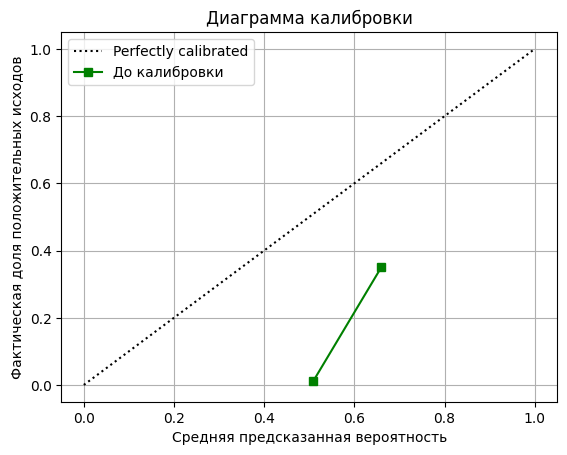


Оценка Бриера: 0.2765

Оценка ECE: 0.4415

Оценка MCE: 0.4981


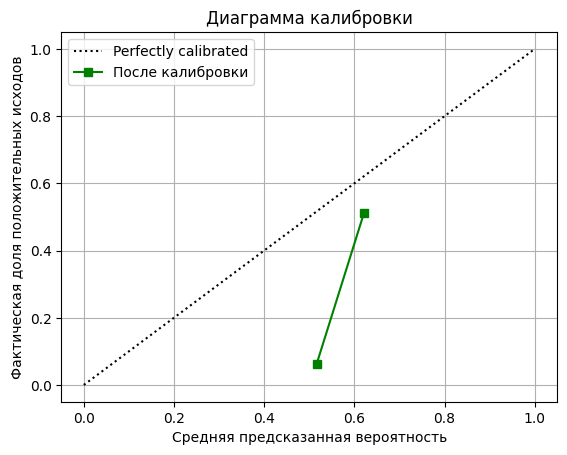


Оценка Бриера: 0.2580

Оценка ECE: 0.4157

Оценка MCE: 0.4542


In [47]:
from sklearn.model_selection import TimeSeriesSplit

best_pipeline = get_ros_pipeline(
    tree_preprocessor,
    RandomForestClassifier(**rf_os_best_params)
)

best_pipeline.fit(X_train, y_train)
y_proba_calib = best_pipeline.predict_proba(X_calib)[:, 1]
check_calibration(y_calib, y_proba_calib, 'До калибровки')

calibrator = CalibratedClassifierCV(
    estimator=best_pipeline,
    method='isotonic',
    cv=TimeSeriesSplit(n_splits=5)
)
calibrator.fit(X_calib, y_calib)

y_proba_calib = calibrator.predict_proba(X_calib)[:, 1]
check_calibration(y_calib, y_proba_calib, 'После калибровки')

Калибровка улучшила значения метрик, модель стала более интерпретируемой, но размах остался прежним, так как модель по-прежнему осторожно относится к своим предсказаниям из-за дисбаланса классов.

## Поиск порога решения

### ! КОММЕНТАРИЙ К РАБОТЕ

Тут тоже задал бы вопрос, а можно ли было реализовать лучше? Часто натыкался на решения с использованием перебора (np.linspace(0, 1, 1001), grid search, optuna), насколько данные методы могли бы быть более подходящими в данном случае?

In [48]:
def find_optimal_threshold(y_true, y_prob, min_approval=0.65, max_default=0.02, max_missed=0.04):
    _, _, thresholds = roc_curve(y_true, y_prob)

    best_threshold = None
    best_score = -1
    best_metrics = {
        "approval_rate": None,
        "default_rate": None,
        "missed_defaults_rate": None,
    }
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        
        tn, _, fn, tp = confusion_matrix(y_true, y_pred).ravel()

        approval_rate = get_approval_rate(fn, tn, len(y_true))
        if approval_rate < min_approval:
            continue
        
        default_rate = get_default_rate(fn, tn)
        if default_rate > max_default:
            continue
        
        missed_defaults_rate = get_missed_defaults_rate(fn, tp)
        if missed_defaults_rate > max_missed:
            continue
        
        # Чем score ближе к 1, тем лучше. Идеальный сценарий: approval=1, default=0, missed=0
        score = approval_rate - default_rate - missed_defaults_rate
        if score > best_score:
            best_score = score
            best_threshold = threshold
            best_metrics = {
                "approval_rate": round(approval_rate * 100, 2),
                "default_rate": round(default_rate * 100, 2),
                "missed_defaults_rate": round(missed_defaults_rate * 100, 2),
            }

    return best_threshold, best_metrics

threshold, metrics = find_optimal_threshold(y_calib, y_proba_calib)
print(f'Оптимальный порог: {threshold}')
print('Лучшие метрики:')
print(f'Approval Rate: {metrics['approval_rate']}%')
print(f'Default Rate: {metrics['default_rate']}%')
print(f'Missed Defaults Rate: {metrics['missed_defaults_rate']}%')

Оптимальный порог: 0.11034346679921928
Лучшие метрики:
Approval Rate: 67.97%
Default Rate: 0.0%
Missed Defaults Rate: 0.0%


Как и ожидалось, лучшим значением стал небольшой порог (0.11) - всё также из-за дисбаланса классов. При этом результаты по метрикам на данных для калибровки стали значения, что удовлетворяют условию ТЗ. 

* Approval Rate: 67.97% > 65%
* Default Rate: 0.0% < 2%
* Missed Defaults Rate: 0.0% < 4%

## Анализ матрицы ошибок

In [49]:
def plot_classification_results(y_test, y_prob, y_pred, thresh, name="Model"):
    _, (ax_conf, ax_prob) = plt.subplots(1, 2, figsize=(16, 6))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_conf)
    ax_conf.set(
        title=f"{name} - Confusion Matrix",
        xlabel="Предсказанные метки",
        ylabel="Актуальные метки"
    )

    df_probs = pd.DataFrame({'Probability': y_prob, 'Actual': y_test})

    sns.histplot(data=df_probs, x='Probability', hue='Actual',
                 element='step', kde=True, bins=30, ax=ax_prob, palette='magma')

    ax_prob.axvline(thresh, color="red", linestyle="--", label=f'Порог {thresh:.2f}')
    ax_prob.set(
        title=f"{name} - Вероятностное распределение по классам",
        xlabel="Предполагаемая вероятность (1)",
        ylabel="Кол-во",
    )
    ax_prob.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

def show_ROC_curve(y_true, y_proba, score, name):
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-кривая (AUC = {score:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC-кривая: {name}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_results(y_true, y_proba, threshold, name):
    y_pred = (y_proba >= threshold).astype(int)
    
    tn, _, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    approval_rate = get_approval_rate(fn, tn, len(y_true))
    default_rate = get_default_rate(fn, tn)
    missed_defaults_rate = get_missed_defaults_rate(fn, tp)
    
    metrics = {
        "Approval Rate": f'{approval_rate * 100:.2f}%',
        "Default Rate": f'{default_rate * 100:.2f}%',
        "Missed Defaults Rate": f'{missed_defaults_rate * 100:.2f}%',
    }
    display(pd.DataFrame([metrics]))

    score = roc_auc_score(y_true, y_proba)
    print(f"[{name}] ROC-AUC: {score:.4f}\n")
    show_ROC_curve(y_true, y_proba, score, name)

    print("Результаты на калибровке с новым порогом")
    print(classification_report(y_true, y_pred, zero_division=0))
    plot_classification_results(y_true, y_proba, y_pred, threshold,  name=name)
    
    return metrics

,Approval Rate,Default Rate,Missed Defaults Rate
0,67.97%,0.00%,0.00%


[Random Forest [Калибровка]] ROC-AUC: 0.9260



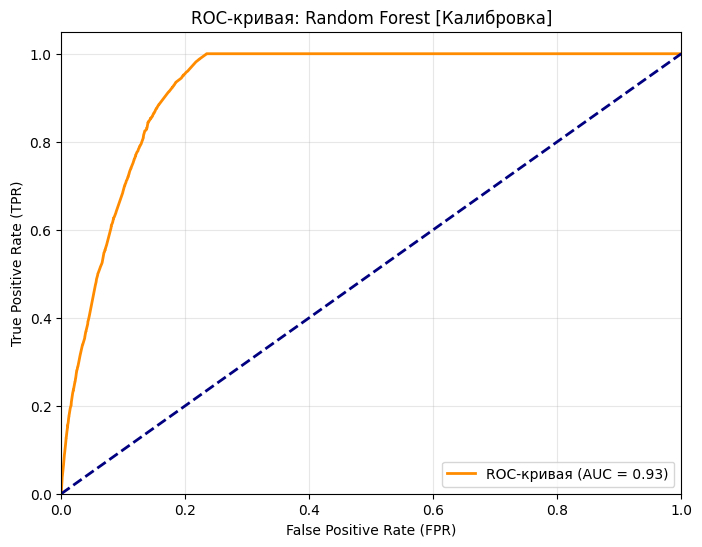

Результаты на калибровке с новым порогом
              precision    recall  f1-score   support

           0       1.00      0.77      0.87     82686
           1       0.35      1.00      0.52     10468

    accuracy                           0.79     93154
   macro avg       0.68      0.88      0.69     93154
weighted avg       0.93      0.79      0.83     93154



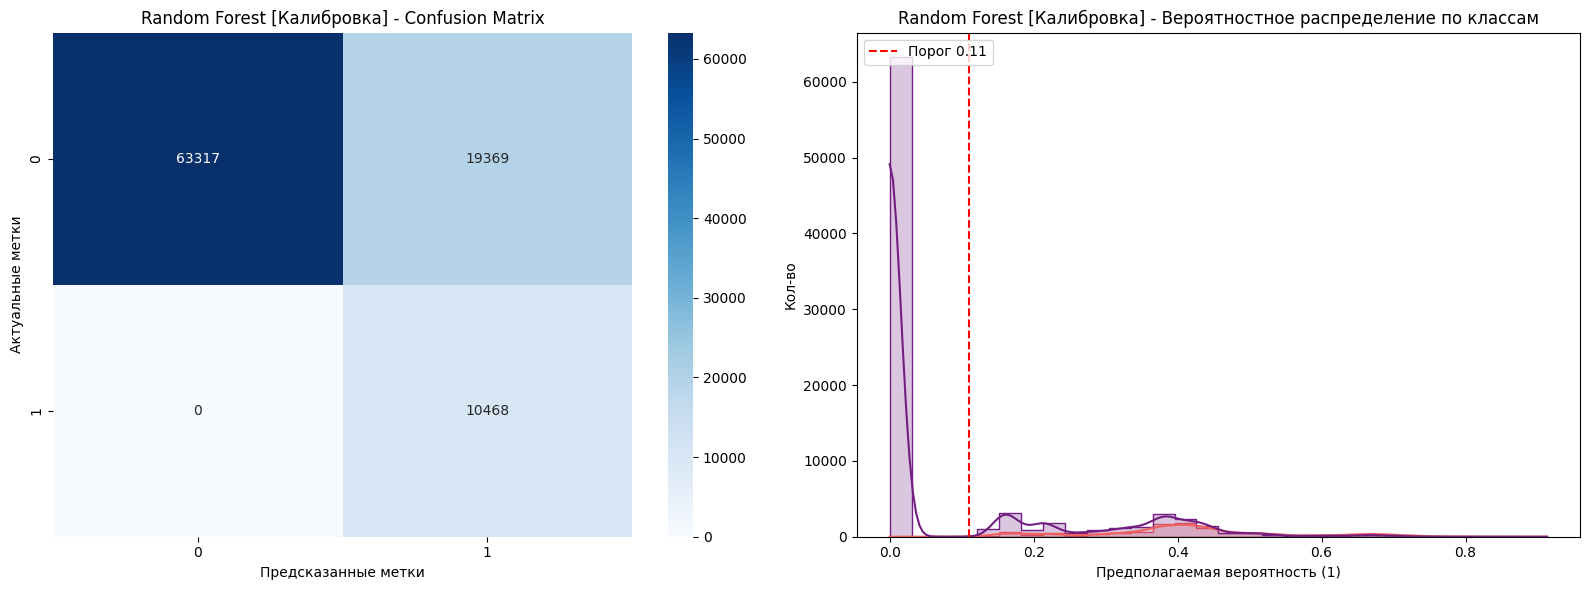

{'Approval Rate': '67.97%',
 'Default Rate': '0.00%',
 'Missed Defaults Rate': '0.00%'}

In [ ]:
_ = evaluate_results(y_calib, y_proba_calib, threshold, 'Random Forest [Калибровка]')

,Approval Rate,Default Rate,Missed Defaults Rate
0,85.58%,0.00%,0.00%


[Random Forest [Тест]] ROC-AUC: 0.9678



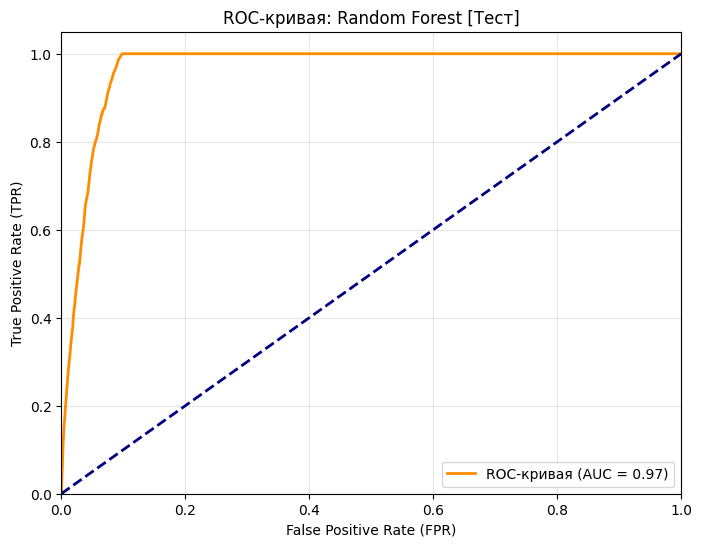

Результаты на калибровке с новым порогом
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    106249
           1       0.36      1.00      0.53      5762

    accuracy                           0.91    112011
   macro avg       0.68      0.95      0.74    112011
weighted avg       0.97      0.91      0.93    112011



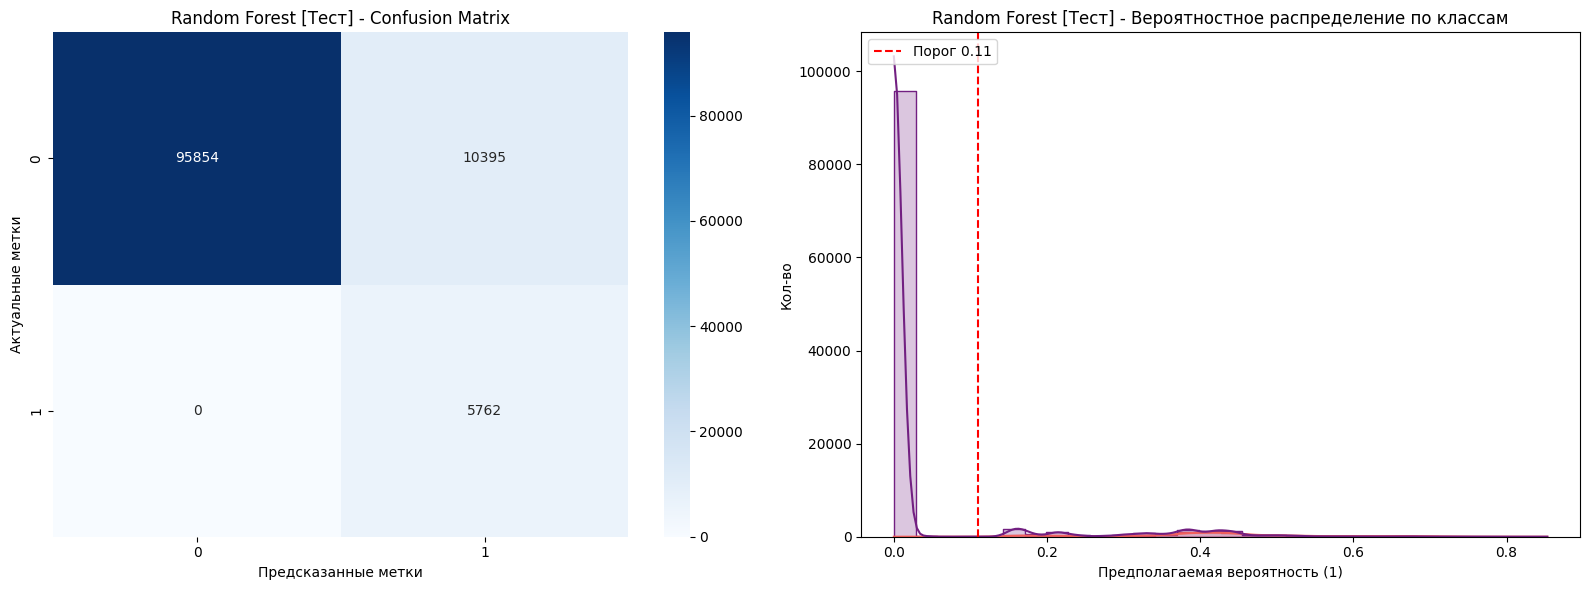

In [51]:
y_proba_test = calibrator.predict_proba(X_test)[:, 1]
metrics = evaluate_results(y_test, y_proba_test, threshold, 'Random Forest [Тест]')

По метрикам на данных для калибровки и теста, можно сделать вывод, что модель не переобучилась, получилось избежать data leakage, так как результат на тесте стал даже немного лучше, чем показатели на данных калибровки. Как и обсуждалось ранее, модель остаётся осторожной и в приоритете стоит отметка клиента как дефолтного, дабы избежать ситуаций, когда неплатежеспособный пользователь не будет найден совсем.

Модель находит 100% всех дефолтных клиентов (recall = 1.0), при этом точность (precision = 0.36) имеет более низкое значение, опять же в силу осторожности. По кастомным метрикам банка получилось также добиться сильных результатов (Approval Rate = 85.58% | Default Rate = 0.0% | Missed Defaults Rate = 0.0%). По графику вероятностного распределения видно, что порог подобран верно и данные разделяются правильно.

## Анализ важности признаков

Прежде чем анализоровать важность признаков, стоит обучить модель полностью на всех доступных данных.

In [94]:
X = df.drop(columns=['target'])
y = df['target']

best_pipeline.fit(X, y)

,steps,"[('preprocessor', ...), ('over', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

In [95]:
def show_feature_importance(pipeline):
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]

    feature_importance = pd.DataFrame(
        {
            "Признак": preprocessor.get_feature_names_out(),
            "Важность": model.feature_importances_ * 100,
        }
    ).sort_values("Важность", ascending=False)

    display(feature_importance \
            .style.format({'importance': '{:.2f}%'}) \
            .background_gradient(cmap='coolwarm'))
    
    top_5_feature_names = feature_importance['Признак'].values[:5]
    top_5_feature_importance = feature_importance['Важность'].values[:5]

    plt.figure(figsize=(8, 5))
    plt.barh(top_5_feature_names, top_5_feature_importance, color='lightseagreen')
    plt.xlabel('Важность признака')
    plt.title('Важность признаков в дереве решений')
    plt.gca().invert_yaxis()
    plt.grid()
    plt.show()

,Признак,Важность
24,num__spend_drop_ratio,26.116618
7,num__client_tenure_days,19.617449
20,num__MCC_другое,12.677983
21,num__total_mcc_spent,11.581792
16,num__MCC_5411,6.085418
18,num__MCC_5722,5.221851
13,num__MCC_5300,4.039728
4,num__доход,3.981408
23,num__loan_to_income_ratio,1.983610
19,num__MCC_4900,1.689509


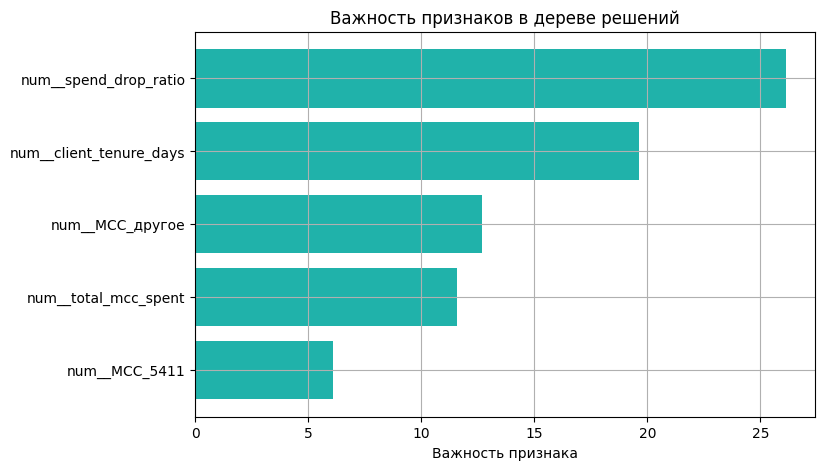

In [96]:
show_feature_importance(best_pipeline)

Самыми важными признаками стали:

- spend_drop_ratio (~26%) - динамика трат пользователя. Данный признак сильнее всего влияет на определение дефолта, так как клиент, чьи траты из месяца в месяц снижаются может демонстрировать слабое финансовое положение.
- client_tenure_days (~20%) - сколько дней пользователь является клиентом банка. Пользователи, которые долго  взаимодействуют с банком, реже становятся дефолтниками.
- MCC_другое (~13%) - траты пользователя в сегменте "Другое" оказывает сильное влияение на результат модели.
- total_mcc_spent (~12%) - общие траты клиента. Индикатор, который полностью отражает платежеспособность, что является весомым фактором целевого признака.
- с меньшим весом далее идут признаки, связанные также с материальным положением - траты по остальным сегментам (mcc_), доход...

К признакам, что совсем не влияют на результат модели относятся:
- Инфляция, как макрофактор.
- Семейное положение клиента.
- Наличие ипотеки.

## Фиксирование итоговой модели


In [97]:
model_file_name = './model.joblib'

metadata = {
    'model_version': '1.0.0',
    'training_date': '2026-02-25',
    'test_metrics': metrics,
    'python_version': sys.version,
    'sklearn_version': sklearn.__version__,
    'pandas_version': pd.__version__,
    'numpy_version': np.__version__
}

joblib.dump({
    'pipeline': best_pipeline,
    'threshold': threshold,
    'metadata': metadata,
}, model_file_name)

print(f"Объект сохранён в файл {model_file_name}") 

Объект сохранён в файл ./model.joblib


In [98]:
class BehaviorscoringPredictionService:
    def __init__(self, model_path):
        self.model = joblib.load(model_path)

    def predict_forecasting(self, data):
        proba = self.model['pipeline'].predict_proba(data)[:, 1]
        return (proba >= self.model['threshold']).astype(int)

In [109]:
service = BehaviorscoringPredictionService(model_file_name)

test_data = df[df['ID'] == 'IDF54897139']
predictions = service.predict_forecasting(test_data.drop(columns='target'))
comparison = test_data[['score_date', 'target']].assign(prediction=predictions)
print(f"Результаты для ID: {id}")
comparison

Результаты для ID: IDF54995533


,score_date,target,prediction
4,2013-02-01,1,1
307,2013-03-01,1,1
1283,2013-04-01,1,1
2060,2013-05-01,1,1
2440,2013-06-01,1,1
3776,2013-07-01,1,1
5377,2013-08-01,1,1
5644,2013-09-01,1,1
8434,2013-10-01,1,1
10166,2013-11-01,1,1


## Выводы по проекту

В ходе проекта была разработана модель поведенческого скоринга, предназначенная для прогнозирования риска дефолта на горизонте 12 месяцев. Работа началась с масштабной подготовки данных: были объединены сведения о платежах, транзакциях и макроэкономических показателях, а для борьбы с дисбалансом классов применены методы ресемплирования. В качестве основного алгоритма был выбран Random Forest с OverSampler, который после настройки гиперпараметров показал высокую точность и стабильность на тестовых выборках.

В качестве основного алгоритма выбран Random Forest Classifier, показавший наиболее стабильные результаты. В процессе работы была выполнена калибровка вероятностей, что привело прогнозные значения модели в соответствие с фактическим уровнем риска. В результате оптимизации бизнес-порога было зафиксировано значение 0,11. На тестовых данных модель продемонстрировала высокую точность: показатель ROC-AUC составил 0,9678, уровень одобрения (Approval Rate) зафиксирован на отметке 85,58%, а доля пропущенных дефолтов (Missed Defaults Rate) в рамках теста составила 0,00%.

Анализ факторов влияния подтвердил, что ключевым предиктором является - структура расходов клиентов. Разработанный финальный пайплайн автоматизирует процесс обработки данных и получения прогноза. Внедрение данной системы в процессы мониторинга позволит банку заблаговременно идентифицировать риски и более эффективно управлять резервами.
